# Title : Evaluating an Email Spam Classification Prototype Using Machine Learning and Deep Learning Models with Cross-Validation.

# Importing Libraries and Loading the dataset 

In [9]:
# I imported the pandas library to perform data manipulation and analysis.
import pandas as pd

# I imported the NumPy library to perform numerical computations and mathematical operations.
import numpy as np

# I loaded the email dataset from the CSV file into a pandas DataFrame.
df = pd.read_csv("emails.csv")

# I displayed a message to confirm that the dataset was loaded successfully.
print("Dataset loaded successfully!")

# I displayed the shape of the dataset to determine the total number of rows and columns.
print("Shape of dataset:", df.shape)

# I displayed a heading before printing the first five records of the dataset.
print("\nFirst 5 rows:\n")

# I displayed the first five rows of the dataset to gain an initial understanding of its structure and contents.
print(df.head())


Dataset loaded successfully!
Shape of dataset: (5728, 2)

First 5 rows:

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1


# Strucure and Overview of the dataset 

In [10]:
# I determined the total number of observations (rows) in the dataset.
num_observations = df.shape[0]

# I determined the total number of features (columns) in the dataset.
num_features = df.shape[1]

# I displayed the total number of observations present in the dataset.
print(f"\nNumber of observations (rows): {num_observations}")

# I initialized a variable to store the detected target variable.
target_col = None

# I iterated through each column in the dataset to identify the target variable.
for col in df.columns:

    # I checked whether the column contained five or fewer unique values and was not of object type.
    if df[col].nunique() <= 5 and df[col].dtype != 'object':

        # I assigned the identified column as the target variable.
        target_col = col

        # I terminated the loop after detecting the first suitable target variable.
        break

# I checked whether a target variable had been identified.
if target_col is None:

    # I assigned the last column as the target variable when no suitable column was detected automatically.
    target_col = df.columns[-1]

# I displayed the detected target variable.
print(f"\nDetected Target Variable: {target_col}")

# I created a list of all independent variables by excluding the target variable.
independent_vars = [col for col in df.columns if col != target_col]

# I displayed a heading for the independent variables.
print("\nIndependent Variables:")

# I displayed the names of all independent variables.
print(independent_vars)

# I displayed a heading for the column information.
print("\nColumn Information:")

# I displayed detailed information about the dataset, including data types, non-null values, and memory usage.
print(df.info())

# I displayed a heading for the statistical summary.
print("\nStatistical Summary:\n")

# I displayed the descriptive statistical summary of the numerical features in the dataset.
print(df.describe())


Number of observations (rows): 5728

Detected Target Variable: spam

Independent Variables:
['text']

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None

Statistical Summary:

              spam
count  5728.000000
mean      0.238827
std       0.426404
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000


# Data Pre-Processing 

In [59]:
# I imported the required libraries for text preprocessing.
import re
import nltk

# I created an English stopword list.
stop_words = set(stopwords.words('english'))

# I initialized the WordNet lemmatizer.
lemmatizer = WordNetLemmatizer()

# I created a function to preprocess the email text.
def preprocess_text(text):

    # I converted the text into lowercase.
    text = text.lower()

    # I removed all URLs from the text.
    text = re.sub(r'http\S+|www\S+', '', text)

    # I removed all email addresses from the text.
    text = re.sub(r'\S+@\S+', '', text)

    # I removed all numbers from the text.
    text = re.sub(r'\d+', '', text)

    # I removed punctuation and special characters from the text.
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # I split the text into individual words.
    words = text.split()

    # I removed stopwords and lemmatized the remaining words.
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # I combined the cleaned words back into a single sentence.
    return " ".join(words)

# I applied the preprocessing function to the email text column.
df['clean_text'] = df['text'].apply(preprocess_text)

# I displayed the first five original and cleaned email texts.
print(df[['text', 'clean_text']].head())

                                                text  \
0  Subject: naturally irresistible your corporate...   
1  Subject: the stock trading gunslinger  fanny i...   
2  Subject: unbelievable new homes made easy  im ...   
3  Subject: 4 color printing special  request add...   
4  Subject: do not have money , get software cds ...   

                                          clean_text  
0  subject naturally irresistible corporate ident...  
1  subject stock trading gunslinger fanny merrill...  
2  subject unbelievable new home made easy im wan...  
3  subject color printing special request additio...  
4  subject money get software cd software compati...  


# Exploratory Data Analysis 

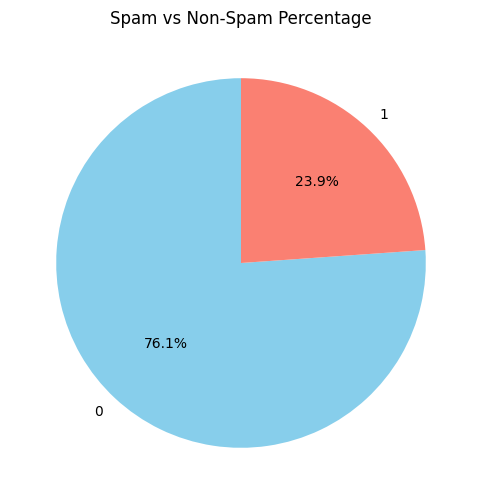

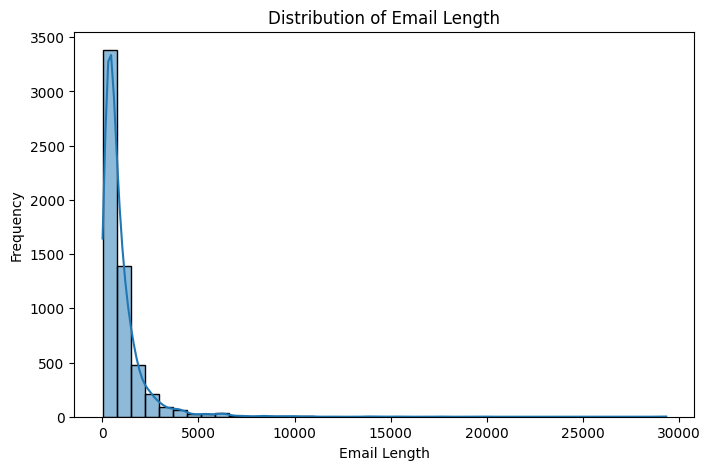

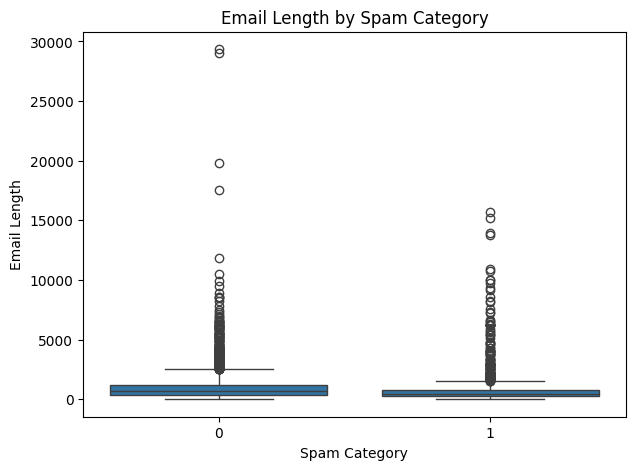

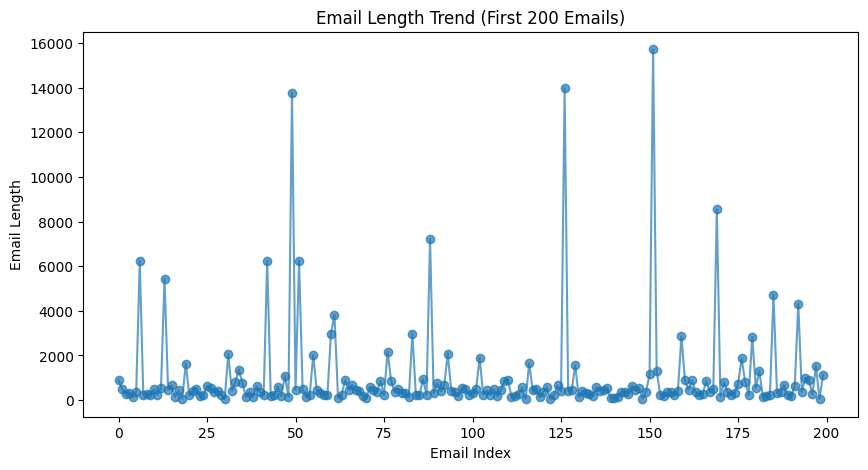

In [12]:
# I imported the matplotlib library for data visualization.
import matplotlib.pyplot as plt

# I imported the seaborn library for statistical visualizations.
import seaborn as sns

# I calculated the length of each cleaned email.
df['email_length'] = df['clean_text'].apply(len)

# I created a figure for the pie chart.
plt.figure(figsize=(6,6))

# I plotted the percentage distribution of spam and non-spam emails.
df['spam'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue','salmon']
)

# I added a title to the pie chart.
plt.title("Spam vs Non-Spam Percentage")

# I removed the default y-axis label.
plt.ylabel('')

# I displayed the pie chart.
plt.show()

# I created a figure for the histogram.
plt.figure(figsize=(8,5))

# I plotted the distribution of email lengths.
sns.histplot(df['email_length'], bins=40, kde=True)

# I added a title to the histogram.
plt.title("Distribution of Email Length")

# I labeled the x-axis.
plt.xlabel("Email Length")

# I labeled the y-axis.
plt.ylabel("Frequency")

# I displayed the histogram.
plt.show()

# I created a figure for the box plot.
plt.figure(figsize=(7,5))

# I plotted the email length distribution for spam and non-spam emails.
sns.boxplot(x='spam', y='email_length', data=df)

# I added a title to the box plot.
plt.title("Email Length by Spam Category")

# I labeled the x-axis.
plt.xlabel("Spam Category")

# I labeled the y-axis.
plt.ylabel("Email Length")

# I displayed the box plot.
plt.show()


# I created a figure for the line graph.
plt.figure(figsize=(10,5))

# I plotted the email length trend for the first 200 emails.
plt.plot(df['email_length'][:200], marker='o', linestyle='-', alpha=0.7)

# I added a title to the line graph.
plt.title("Email Length Trend (First 200 Emails)")

# I labeled the x-axis.
plt.xlabel("Email Index")

# I labeled the y-axis.
plt.ylabel("Email Length")

# I displayed the line graph.
plt.show()

# Feature Extraction Using TF-IDF

In [13]:
# I imported the TfidfVectorizer to convert text into numerical feature vectors.
from sklearn.feature_extraction.text import TfidfVectorizer

# I created a TF-IDF vectorizer.
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

# I converted the cleaned email text into TF-IDF feature vectors.
X = tfidf.fit_transform(df['clean_text'])

# I assigned the target variable.
y = df['spam']

# I displayed the shape of the TF-IDF feature matrix.
print("TF-IDF Feature Matrix Shape:", X.shape)

# I displayed the first twenty extracted feature names.
print("\nFirst 20 Features:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF Feature Matrix Shape: (5728, 5000)

First 20 Features:
['aa' 'ab' 'ab html' 'ability' 'able' 'absence' 'absolutely' 'abstract'
 'ac' 'academic' 'acadia' 'accept' 'acceptable' 'acceptance' 'accepted'
 'access' 'access request' 'accomplish' 'accomplishment' 'according']


# Splitting the dataset into Train and Test Ratio

In [17]:
# I imported the train_test_split function.
from sklearn.model_selection import train_test_split

# I split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed the shape of the training data.
print("Training Features:", X_train.shape)

# I displayed the shape of the testing data.
print("Testing Features:", X_test.shape)

# I displayed the number of training labels.
print("Training Labels:", y_train.shape)

# I displayed the number of testing labels.
print("Testing Labels:", y_test.shape)

Training Features: (4582, 5000)
Testing Features: (1146, 5000)
Training Labels: (4582,)
Testing Labels: (1146,)


# Checking Whether Distribution is Normal or not 

Class Distribution Before SMOTE:

spam
0    3488
1    1094
Name: count, dtype: int64


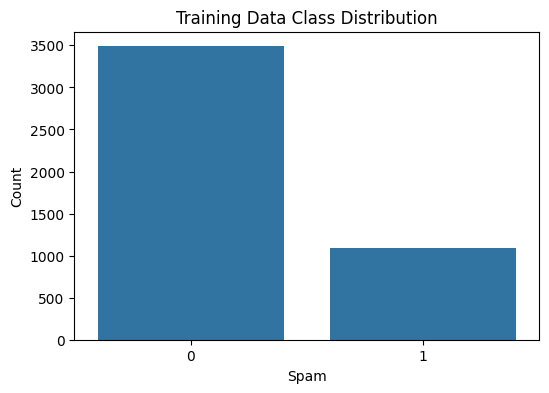

In [18]:
# I displayed the class distribution before applying SMOTE.
print("Class Distribution Before SMOTE:\n")
print(y_train.value_counts())

# I created a bar chart showing the class distribution.
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Data Class Distribution")

plt.xlabel("Spam")

plt.ylabel("Count")

plt.show()

# Applying SMOTE(Synthetic Minority Oversampling Techique) For Balancing the Class

In [19]:
# I imported the SMOTE technique.
from imblearn.over_sampling import SMOTE

# I initialized the SMOTE algorithm.
smote = SMOTE(random_state=42)

# I applied SMOTE to balance the training dataset.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# I displayed the class distribution after SMOTE.
print("Class Distribution After SMOTE:\n")
print(pd.Series(y_train_smote).value_counts())

Class Distribution After SMOTE:

spam
0    3488
1    3488
Name: count, dtype: int64


# Class Distribution After SMOTE 

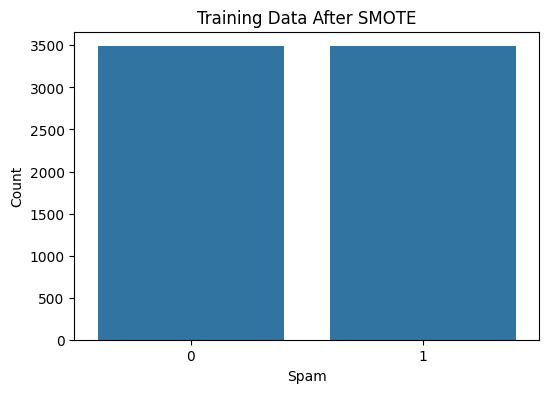

In [20]:
# I created a figure.
plt.figure(figsize=(6,4))

# I plotted the balanced class distribution.
sns.countplot(x=y_train_smote)

# I added the chart title.
plt.title("Training Data After SMOTE")

# I labeled the x-axis.
plt.xlabel("Spam")

# I labeled the y-axis.
plt.ylabel("Count")

# I displayed the chart.
plt.show()

# Model Selection and Training 

# Default Models 

# Model 1 : Logistic Rgression 

In [21]:
# I imported the Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression model.
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I trained the Logistic Regression model using the SMOTE-balanced training data.
lr_model.fit(X_train_smote, y_train_smote)

# I generated predictions on the testing dataset.
y_pred_lr = lr_model.predict(X_test)

# I generated prediction probabilities for ROC-AUC calculation.
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# I calculated and stored the evaluation metrics.
def_lr_acc = accuracy_score(y_test, y_pred_lr)
def_lr_pre = precision_score(y_test, y_pred_lr)
def_lr_rec = recall_score(y_test, y_pred_lr)
def_lr_f1 = f1_score(y_test, y_pred_lr)
def_lr_auc = roc_auc_score(y_test, y_prob_lr)

# I displayed the model performance.
print("Logistic Regression")
print(f"Accuracy : {def_lr_acc:.4f}")
print(f"Precision: {def_lr_pre:.4f}")
print(f"Recall   : {def_lr_rec:.4f}")
print(f"F1-Score : {def_lr_f1:.4f}")
print(f"ROC-AUC  : {def_lr_auc:.4f}")

# I displayed the detailed classification report.
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy : 0.9895
Precision: 0.9679
Recall   : 0.9891
F1-Score : 0.9783
ROC-AUC  : 0.9993

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.97      0.99      0.98       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



# Model 2 : K-Nearest Neighbours (KNN)

In [22]:
# I imported the K-Nearest Neighbors classifier.
from sklearn.neighbors import KNeighborsClassifier

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the K-Nearest Neighbors model.
knn_model = KNeighborsClassifier()

# I trained the K-Nearest Neighbors model using the SMOTE-balanced training data.
knn_model.fit(X_train_smote, y_train_smote)

# I generated predictions on the testing dataset.
y_pred_knn = knn_model.predict(X_test)

# I generated prediction probabilities for ROC-AUC calculation.
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# I calculated and stored the evaluation metrics.
def_knn_acc = accuracy_score(y_test, y_pred_knn)
def_knn_pre = precision_score(y_test, y_pred_knn)
def_knn_rec = recall_score(y_test, y_pred_knn)
def_knn_f1 = f1_score(y_test, y_pred_knn)
def_knn_auc = roc_auc_score(y_test, y_prob_knn)

# I displayed the model performance.
print(" K-Nearest Neighbors")
print(f"Accuracy : {def_knn_acc:.4f}")
print(f"Precision: {def_knn_pre:.4f}")
print(f"Recall   : {def_knn_rec:.4f}")
print(f"F1-Score : {def_knn_f1:.4f}")
print(f"ROC-AUC  : {def_knn_auc:.4f}")

# I displayed the detailed classification report.
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

 K-Nearest Neighbors
Accuracy : 0.7967
Precision: 0.5406
Recall   : 0.9964
F1-Score : 0.7009
ROC-AUC  : 0.9509

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.73      0.85       872
           1       0.54      1.00      0.70       274

    accuracy                           0.80      1146
   macro avg       0.77      0.87      0.77      1146
weighted avg       0.89      0.80      0.81      1146



# Model 3 : Random Forest 

In [23]:
# I imported the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Random Forest model.
rf_model = RandomForestClassifier(
    random_state=42
)

# I trained the Random Forest model using the SMOTE-balanced training data.
rf_model.fit(X_train_smote, y_train_smote)

# I generated predictions on the testing dataset.
y_pred_rf = rf_model.predict(X_test)

# I generated prediction probabilities for ROC-AUC calculation.
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# I calculated and stored the evaluation metrics.
def_rf_acc = accuracy_score(y_test, y_pred_rf)
def_rf_pre = precision_score(y_test, y_pred_rf)
def_rf_rec = recall_score(y_test, y_pred_rf)
def_rf_f1 = f1_score(y_test, y_pred_rf)
def_rf_auc = roc_auc_score(y_test, y_prob_rf)

# I displayed the model performance.
print("Random Forest")
print(f"Accuracy : {def_rf_acc:.4f}")
print(f"Precision: {def_rf_pre:.4f}")
print(f"Recall   : {def_rf_rec:.4f}")
print(f"F1-Score : {def_rf_f1:.4f}")
print(f"ROC-AUC  : {def_rf_auc:.4f}")

# I displayed the detailed classification report.
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy : 0.9895
Precision: 0.9645
Recall   : 0.9927
F1-Score : 0.9784
ROC-AUC  : 0.9990

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.96      0.99      0.98       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



# Model 4 : Artificial Neural Network (ANN)

In [24]:
# I imported the required TensorFlow libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the sparse matrices into dense arrays.
X_train_ann = X_train_smote.toarray()
X_test_ann = X_test.toarray()

# I initialized the Artificial Neural Network model.
ann_model = Sequential()

# I added the input layer and first hidden layer.
ann_model.add(Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)))

# I added the output layer.
ann_model.add(Dense(1, activation='sigmoid'))

# I compiled the Artificial Neural Network model.
ann_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# I trained the Artificial Neural Network model.
ann_model.fit(
    X_train_ann,
    y_train_smote,
    epochs=10,
    batch_size=32,
    verbose=1
)

# I generated prediction probabilities on the testing dataset.
y_prob_ann = ann_model.predict(X_test_ann)

# I converted prediction probabilities into binary class labels.
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

# I calculated and stored the evaluation metrics.
def_ann_acc = accuracy_score(y_test, y_pred_ann)
def_ann_pre = precision_score(y_test, y_pred_ann)
def_ann_rec = recall_score(y_test, y_pred_ann)
def_ann_f1 = f1_score(y_test, y_pred_ann)
def_ann_auc = roc_auc_score(y_test, y_prob_ann)

# I displayed the model performance.
print(" Artificial Neural Network ")
print(f"Accuracy : {def_ann_acc:.4f}")
print(f"Precision: {def_ann_pre:.4f}")
print(f"Recall   : {def_ann_rec:.4f}")
print(f"F1-Score : {def_ann_f1:.4f}")
print(f"ROC-AUC  : {def_ann_auc:.4f}")

# I displayed the detailed classification report.
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_ann))

Epoch 1/10
218/218 [==============================] - 5s 13ms/step - loss: 0.1777 - accuracy: 0.9822
Epoch 2/10
218/218 [==============================] - 3s 14ms/step - loss: 0.0178 - accuracy: 0.9976
Epoch 3/10
218/218 [==============================] - 3s 16ms/step - loss: 0.0064 - accuracy: 0.9997
Epoch 4/10
218/218 [==============================] - 3s 16ms/step - loss: 0.0032 - accuracy: 0.9999
Epoch 5/10
218/218 [==============================] - 3s 13ms/step - loss: 0.0021 - accuracy: 0.9999
Epoch 6/10
218/218 [==============================] - 3s 14ms/step - loss: 0.0014 - accuracy: 0.9999
Epoch 7/10
218/218 [==============================] - 3s 13ms/step - loss: 0.0011 - accuracy: 0.9999
Epoch 8/10
218/218 [==============================] - 3s 13ms/step - loss: 9.2176e-04 - accuracy: 0.9999
Epoch 9/10
218/218 [==============================] - 3s 13ms/step - loss: 7.6493e-04 - accuracy: 0.9999
Epoch 10/10
36/36 [==============================] - 0s 2ms/step
 Artificial Neural

# Model 5 : Deep Neural Network (DNN)

In [25]:
# I imported the required TensorFlow libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the sparse matrices into dense arrays.
X_train_dnn = X_train_smote.toarray()
X_test_dnn = X_test.toarray()

# I initialized the Deep Neural Network model.
dnn_model = Sequential()

# I added the input layer and first hidden layer.
dnn_model.add(Dense(256, activation='relu', input_shape=(X_train_dnn.shape[1],)))

# I added the second hidden layer.
dnn_model.add(Dense(128, activation='relu'))

# I added the third hidden layer.
dnn_model.add(Dense(64, activation='relu'))

# I added the output layer.
dnn_model.add(Dense(1, activation='sigmoid'))

# I compiled the Deep Neural Network model.
dnn_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# I trained the Deep Neural Network model.
dnn_model.fit(
    X_train_dnn,
    y_train_smote,
    epochs=10,
    batch_size=32,
    verbose=1
)

# I generated prediction probabilities on the testing dataset.
y_prob_dnn = dnn_model.predict(X_test_dnn)

# I converted prediction probabilities into binary class labels.
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)

# I calculated and stored the evaluation metrics.
def_dnn_acc = accuracy_score(y_test, y_pred_dnn)
def_dnn_pre = precision_score(y_test, y_pred_dnn)
def_dnn_rec = recall_score(y_test, y_pred_dnn)
def_dnn_f1 = f1_score(y_test, y_pred_dnn)
def_dnn_auc = roc_auc_score(y_test, y_prob_dnn)

# I displayed the model performance.
print("Deep Neural Network")
print(f"Accuracy : {def_dnn_acc:.4f}")
print(f"Precision: {def_dnn_pre:.4f}")
print(f"Recall   : {def_dnn_rec:.4f}")
print(f"F1-Score : {def_dnn_f1:.4f}")
print(f"ROC-AUC  : {def_dnn_auc:.4f}")

# I displayed the detailed classification report.
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dnn))

Epoch 1/10
218/218 [==============================] - 7s 24ms/step - loss: 0.0818 - accuracy: 0.9828
Epoch 2/10
218/218 [==============================] - 6s 27ms/step - loss: 0.0024 - accuracy: 0.9993
Epoch 3/10
218/218 [==============================] - 5s 24ms/step - loss: 7.6490e-04 - accuracy: 0.9997
Epoch 4/10
218/218 [==============================] - 5s 23ms/step - loss: 7.3581e-04 - accuracy: 0.9999
Epoch 5/10
218/218 [==============================] - 5s 21ms/step - loss: 0.0012 - accuracy: 0.9996
Epoch 6/10
218/218 [==============================] - 6s 28ms/step - loss: 5.7034e-04 - accuracy: 0.9997
Epoch 7/10
218/218 [==============================] - 6s 26ms/step - loss: 0.0011 - accuracy: 0.9997
Epoch 8/10
218/218 [==============================] - 6s 25ms/step - loss: 6.8027e-04 - accuracy: 0.9999
Epoch 9/10
218/218 [==============================] - 6s 27ms/step - loss: 0.0012 - accuracy: 0.9997
Epoch 10/10
36/36 [==============================] - 0s 4ms/step
Deep Neura

# Combined Comparative Table for all Default Models 

In [26]:
# I created a DataFrame containing the performance of all baseline models.
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest",
        "Artificial Neural Network",
        "Deep Neural Network"
    ],
    "Accuracy": [
        def_lr_acc,
        def_knn_acc,
        def_rf_acc,
        def_ann_acc,
        def_dnn_acc
    ],
    "Precision": [
        def_lr_pre,
        def_knn_pre,
        def_rf_pre,
        def_ann_pre,
        def_dnn_pre
    ],
    "Recall": [
        def_lr_rec,
        def_knn_rec,
        def_rf_rec,
        def_ann_rec,
        def_dnn_rec
    ],
    "F1-Score": [
        def_lr_f1,
        def_knn_f1,
        def_rf_f1,
        def_ann_f1,
        def_dnn_f1
    ],
    "ROC-AUC": [
        def_lr_auc,
        def_knn_auc,
        def_rf_auc,
        def_ann_auc,
        def_dnn_auc
    ]
})

# I rounded the evaluation metrics.
baseline_results.iloc[:,1:] = baseline_results.iloc[:,1:].round(4)

# I sorted the models based on accuracy.
baseline_results = baseline_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# I displayed the comparative table with colours.
baseline_results.style\
    .background_gradient(
        cmap="YlGn",
        subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
    )\
    .set_caption("Comparative Performance of Baseline Models")\
    .set_properties(**{
        "text-align":"center",
        "border":"1px solid black"
    })\
    .set_table_styles([
        {
            "selector":"th",
            "props":[
                ("background-color","#2F5597"),
                ("color","white"),
                ("font-weight","bold"),
                ("text-align","center")
            ]
        },
        {
            "selector":"caption",
            "props":[
                ("font-size","16px"),
                ("font-weight","bold")
            ]
        }
    ])

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Artificial Neural Network,0.992100,0.981800,0.985400,0.983600,0.999700
1,Deep Neural Network,0.991300,0.974800,0.989100,0.981900,0.999600
2,Logistic Regression,0.989500,0.967900,0.989100,0.978300,0.999300
3,Random Forest,0.989500,0.964500,0.992700,0.978400,0.999000
4,K-Nearest Neighbors,0.796700,0.540600,0.996400,0.700900,0.950900


# Visual Analysis for each metric for default models 

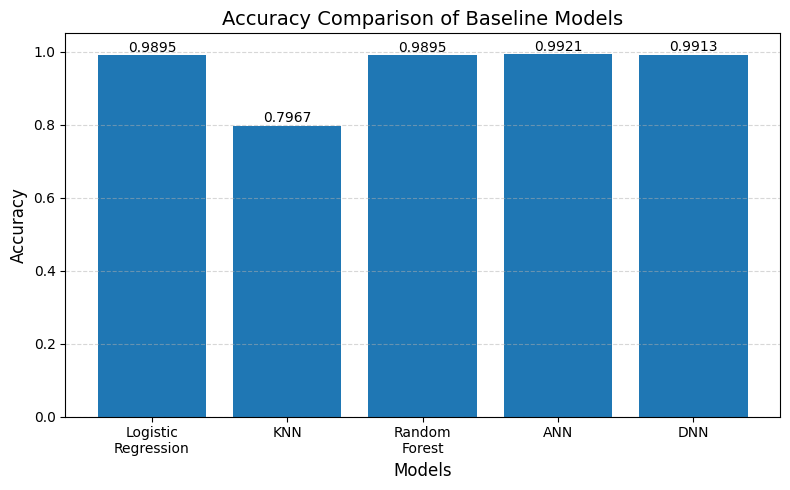

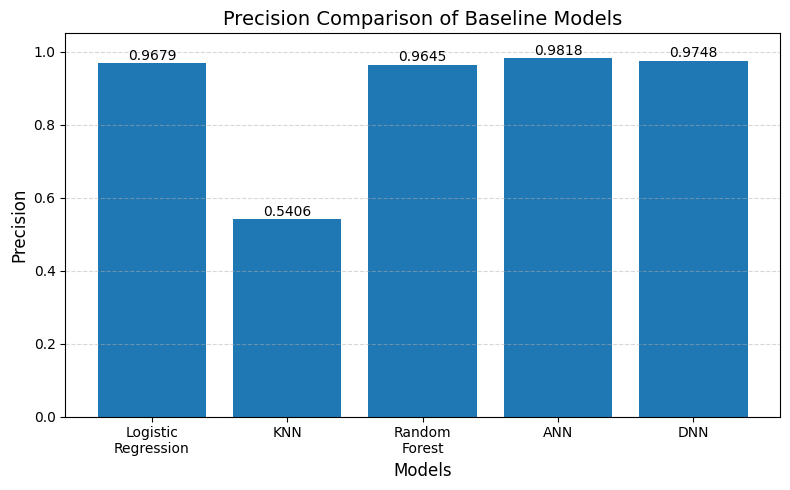

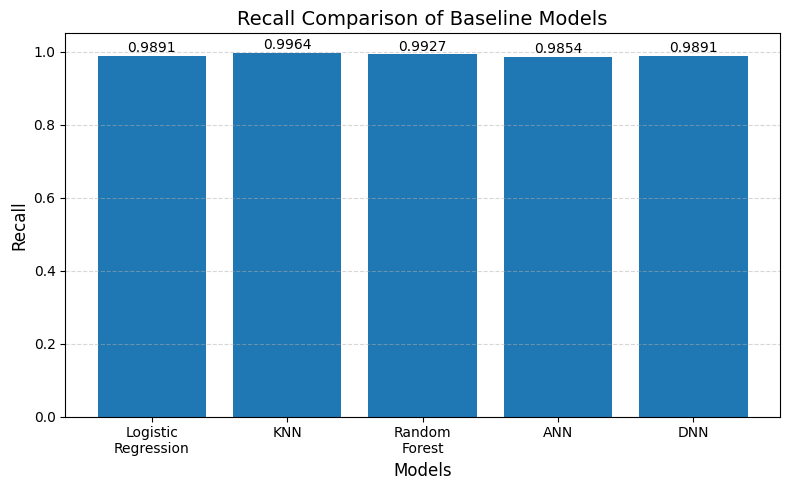

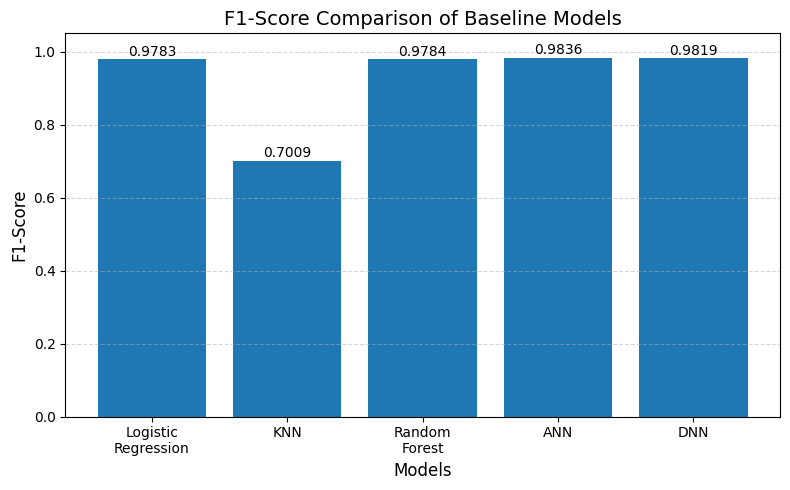

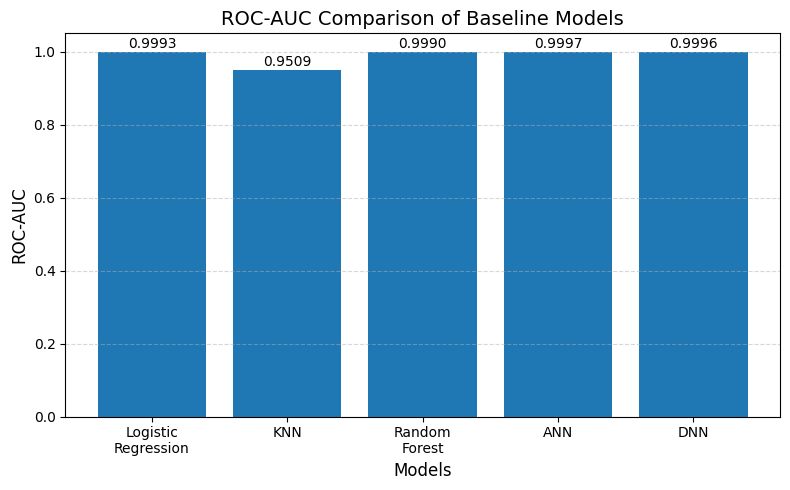

In [27]:
# I imported the matplotlib library for visualization.
import matplotlib.pyplot as plt

# I created lists containing the model names and evaluation metrics.
models = [
    "Logistic\nRegression",
    "KNN",
    "Random\nForest",
    "ANN",
    "DNN"
]

accuracy = [
    def_lr_acc,
    def_knn_acc,
    def_rf_acc,
    def_ann_acc,
    def_dnn_acc
]

precision = [
    def_lr_pre,
    def_knn_pre,
    def_rf_pre,
    def_ann_pre,
    def_dnn_pre
]

recall = [
    def_lr_rec,
    def_knn_rec,
    def_rf_rec,
    def_ann_rec,
    def_dnn_rec
]

f1_score_values = [
    def_lr_f1,
    def_knn_f1,
    def_rf_f1,
    def_ann_f1,
    def_dnn_f1
]

roc_auc = [
    def_lr_auc,
    def_knn_auc,
    def_rf_auc,
    def_ann_auc,
    def_dnn_auc
]

# I stored all evaluation metrics in a dictionary.
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score_values,
    "ROC-AUC": roc_auc
}

# I generated a separate bar chart for each evaluation metric.
for metric_name, values in metrics.items():

    plt.figure(figsize=(8,5))

    bars = plt.bar(models, values)

    plt.title(f"{metric_name} Comparison of Baseline Models", fontsize=14)

    plt.xlabel("Models", fontsize=12)

    plt.ylabel(metric_name, fontsize=12)

    plt.ylim(0, 1.05)

    # I displayed the metric value above each bar.
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.4f}",
            ha='center',
            fontsize=10
        )

    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()

    plt.show()

# Combined Comparative Bar Graph for all Default Models 

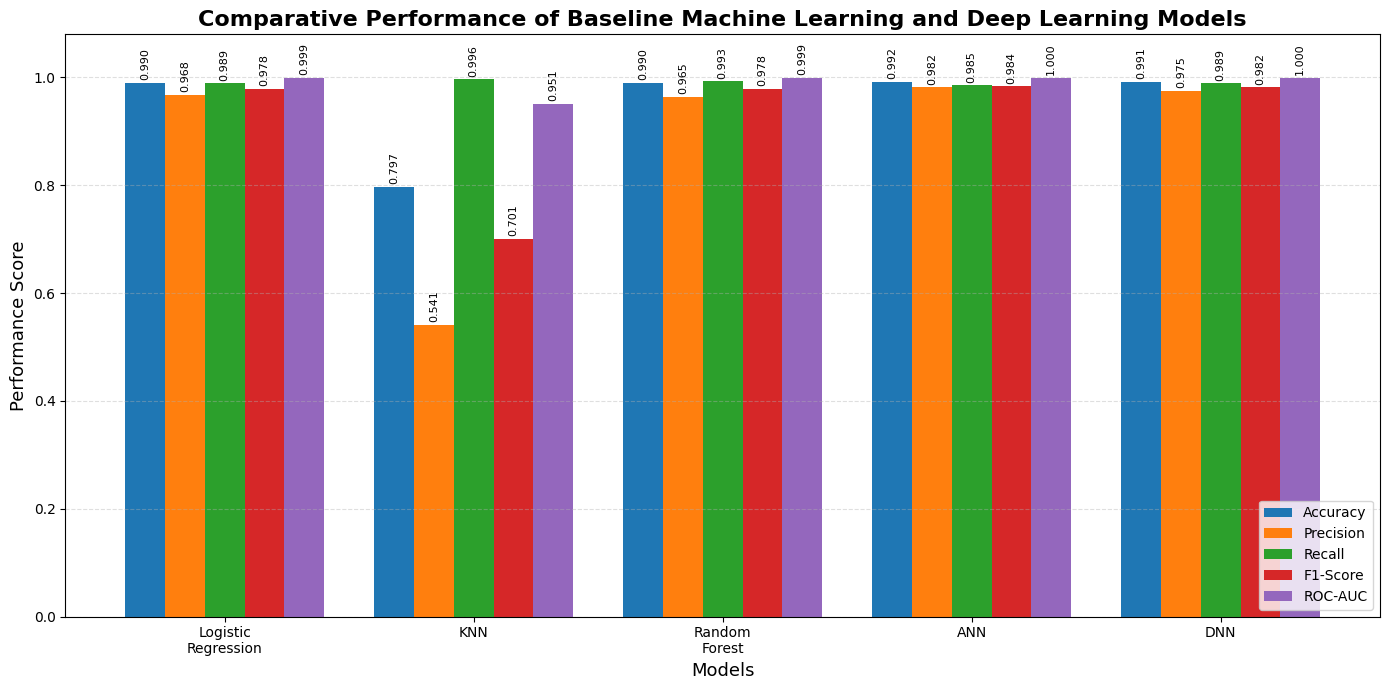

In [28]:
# I imported the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# I created a list containing the model names.
models = [
    "Logistic\nRegression",
    "KNN",
    "Random\nForest",
    "ANN",
    "DNN"
]

# I created lists containing the evaluation metrics.
accuracy = [def_lr_acc, def_knn_acc, def_rf_acc, def_ann_acc, def_dnn_acc]
precision = [def_lr_pre, def_knn_pre, def_rf_pre, def_ann_pre, def_dnn_pre]
recall = [def_lr_rec, def_knn_rec, def_rf_rec, def_ann_rec, def_dnn_rec]
f1 = [def_lr_f1, def_knn_f1, def_rf_f1, def_ann_f1, def_dnn_f1]
roc_auc = [def_lr_auc, def_knn_auc, def_rf_auc, def_ann_auc, def_dnn_auc]

# I defined the x-axis positions.
x = np.arange(len(models))

# I defined the width of each bar.
width = 0.16

# I created the figure.
plt.figure(figsize=(14,7))

# I plotted the grouped bars.
plt.bar(x - 2*width, accuracy, width, label='Accuracy')
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-Score')
plt.bar(x + 2*width, roc_auc, width, label='ROC-AUC')

# I added the metric values above each bar.
for i, values in enumerate([accuracy, precision, recall, f1, roc_auc]):
    offset = (-2 + i) * width
    for j, value in enumerate(values):
        plt.text(
            x[j] + offset,
            value + 0.005,
            f"{value:.3f}",
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

# I customized the graph.
plt.title("Comparative Performance of Baseline Machine Learning and Deep Learning Models", fontsize=16, fontweight='bold')
plt.xlabel("Models", fontsize=13)
plt.ylabel("Performance Score", fontsize=13)
plt.xticks(x, models)
plt.ylim(0, 1.08)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# I displayed the legend.
plt.legend(loc='lower right')

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Cross Validation : To Prove Overfitting not occured 

# Model 1 : Logistic Regression

In [29]:
# I imported the required libraries for cross-validation.
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

# I initialized the Logistic Regression model.
lr_cv_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I defined the evaluation metrics for cross-validation.
scoring = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

# I performed 5-fold cross-validation on the SMOTE-balanced training dataset.
lr_cv_results = cross_validate(
    estimator=lr_cv_model,
    X=X_train_smote,
    y=y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

# I calculated the average cross-validation scores.
cv_lr_acc = lr_cv_results['test_accuracy'].mean()
cv_lr_pre = lr_cv_results['test_precision'].mean()
cv_lr_rec = lr_cv_results['test_recall'].mean()
cv_lr_f1 = lr_cv_results['test_f1'].mean()
cv_lr_auc = lr_cv_results['test_roc_auc'].mean()

# I displayed the average cross-validation results.
print(" Logistic Regression Cross-Validation \n")

print(f"Average Accuracy : {cv_lr_acc:.4f}")
print(f"Average Precision: {cv_lr_pre:.4f}")
print(f"Average Recall   : {cv_lr_rec:.4f}")
print(f"Average F1-Score : {cv_lr_f1:.4f}")
print(f"Average ROC-AUC  : {cv_lr_auc:.4f}")

# I displayed the score obtained in each fold.
cv_results_lr = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": lr_cv_results['test_accuracy'],
    "Precision": lr_cv_results['test_precision'],
    "Recall": lr_cv_results['test_recall'],
    "F1-Score": lr_cv_results['test_f1'],
    "ROC-AUC": lr_cv_results['test_roc_auc']
})

print("\n Cross-Validation Scores for Each Fold \n")
print(cv_results_lr.round(4))

 Logistic Regression Cross-Validation 

Average Accuracy : 0.9930
Average Precision: 0.9886
Average Recall   : 0.9974
Average F1-Score : 0.9930
Average ROC-AUC  : 0.9996

 Cross-Validation Scores for Each Fold 

   Fold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0     1    0.9907     0.9858  0.9957    0.9907   0.9993
1     2    0.9907     0.9872  0.9943    0.9907   0.9993
2     3    0.9971     0.9943  1.0000    0.9971   1.0000
3     4    0.9943     0.9901  0.9986    0.9943   0.9995
4     5    0.9921     0.9859  0.9986    0.9922   0.9999


# Model 2 : KNN

In [30]:
# I imported the required libraries for cross-validation.
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier

# I initialized the K-Nearest Neighbors model.
knn_cv_model = KNeighborsClassifier()

# I defined the evaluation metrics for cross-validation.
scoring = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

# I performed 5-fold cross-validation on the SMOTE-balanced training dataset.
knn_cv_results = cross_validate(
    estimator=knn_cv_model,
    X=X_train_smote,
    y=y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

# I calculated the average cross-validation scores.
cv_knn_acc = knn_cv_results['test_accuracy'].mean()
cv_knn_pre = knn_cv_results['test_precision'].mean()
cv_knn_rec = knn_cv_results['test_recall'].mean()
cv_knn_f1 = knn_cv_results['test_f1'].mean()
cv_knn_auc = knn_cv_results['test_roc_auc'].mean()

# I displayed the average cross-validation results.
print("K-Nearest Neighbors Cross-Validation Results\n")

print(f"Average Accuracy : {cv_knn_acc:.4f}")
print(f"Average Precision: {cv_knn_pre:.4f}")
print(f"Average Recall   : {cv_knn_rec:.4f}")
print(f"Average F1-Score : {cv_knn_f1:.4f}")
print(f"Average ROC-AUC  : {cv_knn_auc:.4f}")

# I displayed the score obtained in each fold.
cv_results_knn = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": knn_cv_results['test_accuracy'],
    "Precision": knn_cv_results['test_precision'],
    "Recall": knn_cv_results['test_recall'],
    "F1-Score": knn_cv_results['test_f1'],
    "ROC-AUC": knn_cv_results['test_roc_auc']
})

print("\nCross-Validation Scores for Each Fold\n")
print(cv_results_knn.round(4))

K-Nearest Neighbors Cross-Validation Results

Average Accuracy : 0.8707
Average Precision: 0.7948
Average Recall   : 0.9997
Average F1-Score : 0.8855
Average ROC-AUC  : 0.9558

Cross-Validation Scores for Each Fold

   Fold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0     1    0.8689     0.7929  0.9986    0.8840   0.9515
1     2    0.8573     0.7779  1.0000    0.8751   0.9474
2     3    0.8738     0.7984  1.0000    0.8879   0.9639
3     4    0.8731     0.7977  1.0000    0.8875   0.9530
4     5    0.8803     0.8069  1.0000    0.8932   0.9630


# Model 3 : Random Forest 

In [31]:
# I imported the required libraries for cross-validation.
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

# I initialized the Random Forest model.
rf_cv_model = RandomForestClassifier(
    random_state=42
)

# I defined the evaluation metrics for cross-validation.
scoring = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

# I performed 5-fold cross-validation on the SMOTE-balanced training dataset.
rf_cv_results = cross_validate(
    estimator=rf_cv_model,
    X=X_train_smote,
    y=y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

# I calculated the average cross-validation scores.
cv_rf_acc = rf_cv_results['test_accuracy'].mean()
cv_rf_pre = rf_cv_results['test_precision'].mean()
cv_rf_rec = rf_cv_results['test_recall'].mean()
cv_rf_f1 = rf_cv_results['test_f1'].mean()
cv_rf_auc = rf_cv_results['test_roc_auc'].mean()

# I displayed the average cross-validation results.
print("Random Forest Cross-Validation Results\n")

print(f"Average Accuracy : {cv_rf_acc:.4f}")
print(f"Average Precision: {cv_rf_pre:.4f}")
print(f"Average Recall   : {cv_rf_rec:.4f}")
print(f"Average F1-Score : {cv_rf_f1:.4f}")
print(f"Average ROC-AUC  : {cv_rf_auc:.4f}")

# I displayed the score obtained in each fold.
cv_results_rf = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": rf_cv_results['test_accuracy'],
    "Precision": rf_cv_results['test_precision'],
    "Recall": rf_cv_results['test_recall'],
    "F1-Score": rf_cv_results['test_f1'],
    "ROC-AUC": rf_cv_results['test_roc_auc']
})

print("\nCross-Validation Scores for Each Fold\n")
print(cv_results_rf.round(4))

Random Forest Cross-Validation Results

Average Accuracy : 0.9923
Average Precision: 0.9881
Average Recall   : 0.9966
Average F1-Score : 0.9923
Average ROC-AUC  : 0.9998

Cross-Validation Scores for Each Fold

   Fold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0     1    0.9878     0.9899  0.9857    0.9878   0.9995
1     2    0.9943     0.9914  0.9971    0.9943   0.9995
2     3    0.9964     0.9929  1.0000    0.9964   1.0000
3     4    0.9900     0.9803  1.0000    0.9901   1.0000
4     5    0.9928     0.9859  1.0000    0.9929   1.0000


# Model 4 : ANN

In [32]:
# I imported the required libraries for cross-validation.
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_validate
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# I created a function to build the Artificial Neural Network model.
def create_ann_model():

    model = Sequential()

    model.add(Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# I initialized the ANN model.
ann_cv_model = KerasClassifier(
    model=create_ann_model,
    epochs=10,
    batch_size=32,
    verbose=0
)

# I defined the evaluation metrics for cross-validation.
scoring = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

# I performed 5-fold cross-validation on the SMOTE-balanced training dataset.
ann_cv_results = cross_validate(
    estimator=ann_cv_model,
    X=X_train_ann,
    y=y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=1
)

# I calculated the average cross-validation scores.
cv_ann_acc = ann_cv_results['test_accuracy'].mean()
cv_ann_pre = ann_cv_results['test_precision'].mean()
cv_ann_rec = ann_cv_results['test_recall'].mean()
cv_ann_f1 = ann_cv_results['test_f1'].mean()
cv_ann_auc = ann_cv_results['test_roc_auc'].mean()

# I displayed the average cross-validation results.
print("Artificial Neural Network Cross-Validation Results\n")

print(f"Average Accuracy : {cv_ann_acc:.4f}")
print(f"Average Precision: {cv_ann_pre:.4f}")
print(f"Average Recall   : {cv_ann_rec:.4f}")
print(f"Average F1-Score : {cv_ann_f1:.4f}")
print(f"Average ROC-AUC  : {cv_ann_auc:.4f}")

# I displayed the score obtained in each fold.
cv_results_ann = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": ann_cv_results['test_accuracy'],
    "Precision": ann_cv_results['test_precision'],
    "Recall": ann_cv_results['test_recall'],
    "F1-Score": ann_cv_results['test_f1'],
    "ROC-AUC": ann_cv_results['test_roc_auc']
})

print("\nCross-Validation Scores for Each Fold\n")
print(cv_results_ann.round(4))

Artificial Neural Network Cross-Validation Results

Average Accuracy : 0.9968
Average Precision: 0.9943
Average Recall   : 0.9994
Average F1-Score : 0.9969
Average ROC-AUC  : 0.9999

Cross-Validation Scores for Each Fold

   Fold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0     1    0.9986     0.9971  1.0000    0.9986   0.9999
1     2    0.9950     0.9929  0.9971    0.9950   0.9998
2     3    0.9993     0.9986  1.0000    0.9993   1.0000
3     4    0.9964     0.9929  1.0000    0.9964   1.0000
4     5    0.9950     0.9901  1.0000    0.9950   1.0000


# Model 5 : DNN

In [33]:
# I imported the required libraries for cross-validation.
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_validate
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# I created a function to build the Deep Neural Network model.
def create_dnn_model():

    model = Sequential()

    model.add(Dense(256, activation='relu', input_shape=(X_train_dnn.shape[1],)))

    model.add(Dense(128, activation='relu'))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# I initialized the Deep Neural Network model.
dnn_cv_model = KerasClassifier(
    model=create_dnn_model,
    epochs=10,
    batch_size=32,
    verbose=0
)

# I defined the evaluation metrics for cross-validation.
scoring = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

# I performed 5-fold cross-validation on the SMOTE-balanced training dataset.
dnn_cv_results = cross_validate(
    estimator=dnn_cv_model,
    X=X_train_dnn,
    y=y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=1
)

# I calculated the average cross-validation scores.
cv_dnn_acc = dnn_cv_results['test_accuracy'].mean()
cv_dnn_pre = dnn_cv_results['test_precision'].mean()
cv_dnn_rec = dnn_cv_results['test_recall'].mean()
cv_dnn_f1 = dnn_cv_results['test_f1'].mean()
cv_dnn_auc = dnn_cv_results['test_roc_auc'].mean()

# I displayed the average cross-validation results.
print("Deep Neural Network Cross-Validation Results\n")

print(f"Average Accuracy : {cv_dnn_acc:.4f}")
print(f"Average Precision: {cv_dnn_pre:.4f}")
print(f"Average Recall   : {cv_dnn_rec:.4f}")
print(f"Average F1-Score : {cv_dnn_f1:.4f}")
print(f"Average ROC-AUC  : {cv_dnn_auc:.4f}")

# I displayed the score obtained in each fold.
cv_results_dnn = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": dnn_cv_results['test_accuracy'],
    "Precision": dnn_cv_results['test_precision'],
    "Recall": dnn_cv_results['test_recall'],
    "F1-Score": dnn_cv_results['test_f1'],
    "ROC-AUC": dnn_cv_results['test_roc_auc']
})

print("\nCross-Validation Scores for Each Fold\n")
print(cv_results_dnn.round(4))

Deep Neural Network Cross-Validation Results

Average Accuracy : 0.9946
Average Precision: 0.9898
Average Recall   : 0.9994
Average F1-Score : 0.9946
Average ROC-AUC  : 0.9999

Cross-Validation Scores for Each Fold

   Fold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0     1    0.9914     0.9831  1.0000    0.9915   0.9998
1     2    0.9943     0.9914  0.9971    0.9943   0.9997
2     3    0.9993     0.9986  1.0000    0.9993   1.0000
3     4    0.9950     0.9901  1.0000    0.9950   0.9999
4     5    0.9928     0.9859  1.0000    0.9929   1.0000


# Combined Comparative Table for all Cross-Validation Models 

In [34]:
# I created a DataFrame to compare the cross-validation performance of all models.
cross_validation_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest",
        "Artificial Neural Network",
        "Deep Neural Network"
    ],
    "Accuracy": [
        cv_lr_acc,
        cv_knn_acc,
        cv_rf_acc,
        cv_ann_acc,
        cv_dnn_acc
    ],
    "Precision": [
        cv_lr_pre,
        cv_knn_pre,
        cv_rf_pre,
        cv_ann_pre,
        cv_dnn_pre
    ],
    "Recall": [
        cv_lr_rec,
        cv_knn_rec,
        cv_rf_rec,
        cv_ann_rec,
        cv_dnn_rec
    ],
    "F1-Score": [
        cv_lr_f1,
        cv_knn_f1,
        cv_rf_f1,
        cv_ann_f1,
        cv_dnn_f1
    ],
    "ROC-AUC": [
        cv_lr_auc,
        cv_knn_auc,
        cv_rf_auc,
        cv_ann_auc,
        cv_dnn_auc
    ]
})

# I rounded the numerical values to four decimal places.
cross_validation_results.iloc[:, 1:] = cross_validation_results.iloc[:, 1:].round(4)

# I sorted the models based on Accuracy.
cross_validation_results = cross_validation_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# I displayed the comparative cross-validation results.
print("Comparative Cross-Validation Performance of Machine Learning and Deep Learning Models\n")
print(cross_validation_results)

# I displayed the cross-validation comparison table with formatting.
cross_validation_results.style\
.background_gradient(cmap="YlGn", subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])\
.set_caption("Comparative Cross-Validation Performance of Machine Learning and Deep Learning Models")\
.set_properties(**{
    "text-align": "center",
    "font-size": "12px"
})\
.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("background-color", "#40466e"),
            ("color", "white"),
            ("text-align", "center"),
            ("font-size", "12px")
        ]
    },
    {
        "selector": "caption",
        "props": [
            ("font-size", "14px"),
            ("font-weight", "bold")
        ]
    }
])

Comparative Cross-Validation Performance of Machine Learning and Deep Learning Models

                       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Artificial Neural Network    0.9968     0.9943  0.9994    0.9969   0.9999
1        Deep Neural Network    0.9946     0.9898  0.9994    0.9946   0.9999
2        Logistic Regression    0.9930     0.9886  0.9974    0.9930   0.9996
3              Random Forest    0.9923     0.9881  0.9966    0.9923   0.9998
4        K-Nearest Neighbors    0.8707     0.7948  0.9997    0.8855   0.9558


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Artificial Neural Network,0.996800,0.994300,0.999400,0.996900,0.999900
1,Deep Neural Network,0.994600,0.989800,0.999400,0.994600,0.999900
2,Logistic Regression,0.993000,0.988600,0.997400,0.993000,0.999600
3,Random Forest,0.992300,0.988100,0.996600,0.992300,0.999800
4,K-Nearest Neighbors,0.870700,0.794800,0.999700,0.885500,0.955800


# Visual Analysis for each metric 

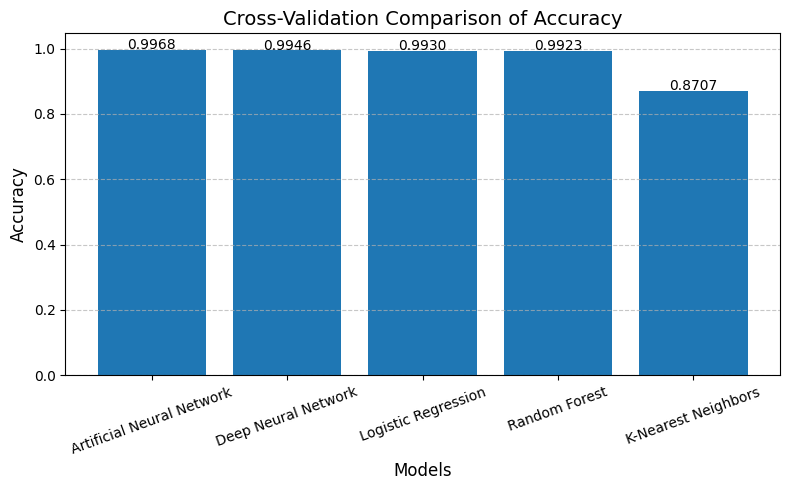

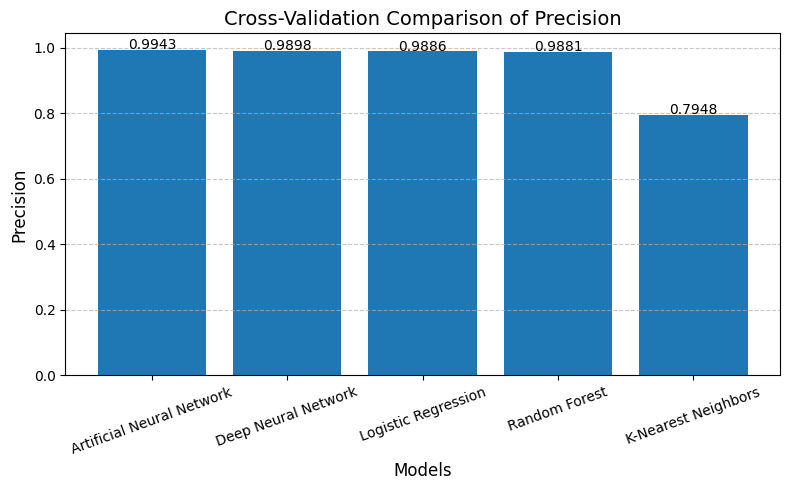

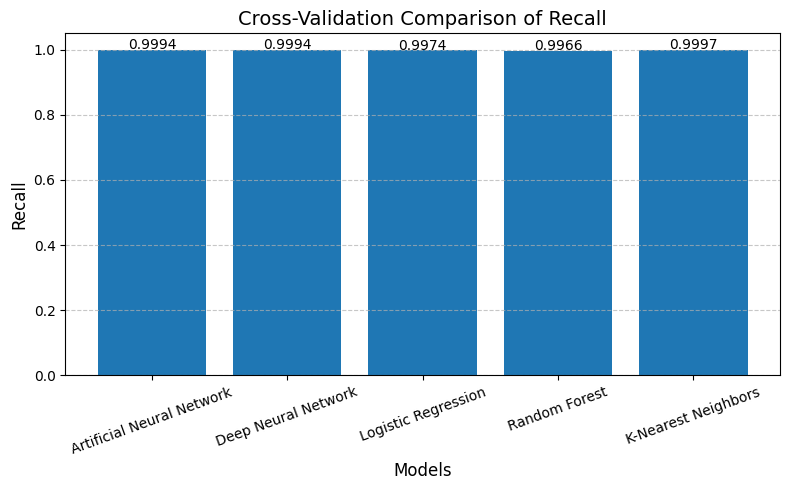

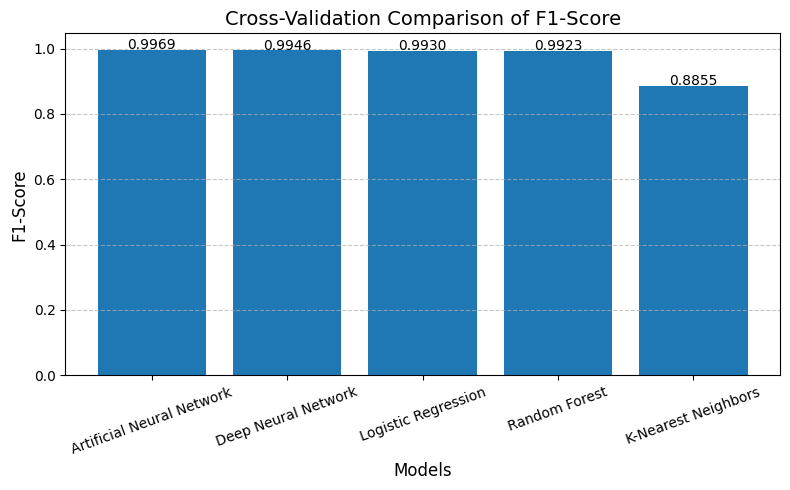

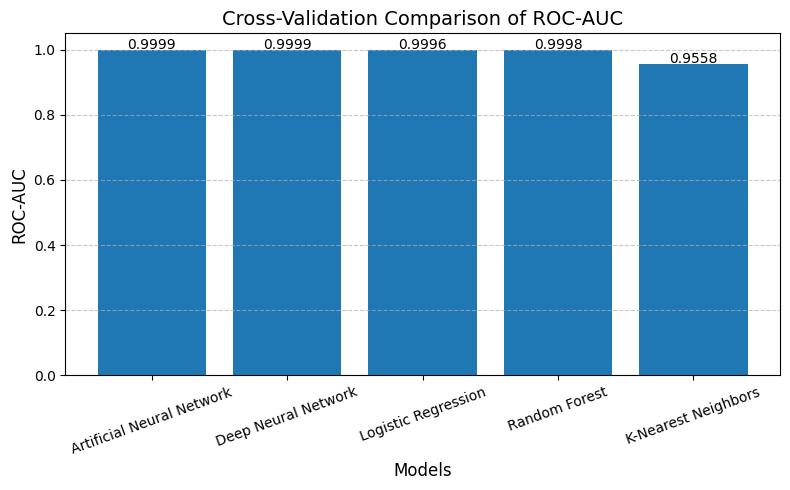

In [35]:
# I imported the required library for data visualization.
import matplotlib.pyplot as plt

# I defined the performance metrics to be visualized.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# I generated a separate bar chart for each evaluation metric.
for metric in metrics:

    plt.figure(figsize=(8, 5))

    bars = plt.bar(
        cross_validation_results["Model"],
        cross_validation_results[metric]
    )

    # I added the values on the top of each bar.
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.4f}",
            ha="center",
            fontsize=10
        )

    # I added the chart title and axis labels.
    plt.title(f"Cross-Validation Comparison of {metric}", fontsize=14)
    plt.xlabel("Models", fontsize=12)
    plt.ylabel(metric, fontsize=12)

    # I rotated the x-axis labels for better readability.
    plt.xticks(rotation=20)

    # I added a grid to improve readability.
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # I adjusted the layout.
    plt.tight_layout()

    # I displayed the chart.
    plt.show()

# Combined Comparative Bar Graph for all Cross-Validation Models 

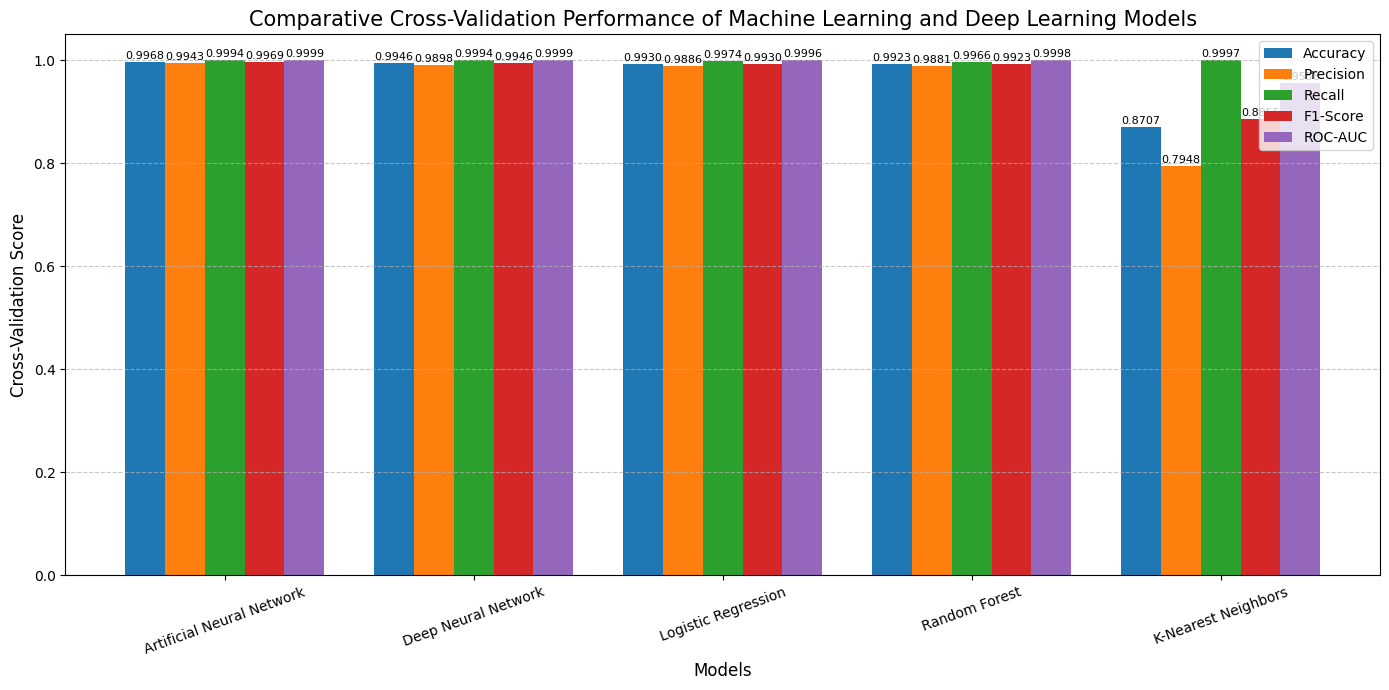

In [38]:
# I imported the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# I defined the evaluation metrics.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# I defined the model names.
models = cross_validation_results["Model"]

# I created the x-axis positions.
x = np.arange(len(models))

# I defined the width of each bar.
width = 0.16

# I created the figure.
plt.figure(figsize=(14, 7))

# I plotted the grouped bars for each evaluation metric.
bars1 = plt.bar(x - 2 * width, cross_validation_results["Accuracy"], width, label="Accuracy")
bars2 = plt.bar(x - width, cross_validation_results["Precision"], width, label="Precision")
bars3 = plt.bar(x, cross_validation_results["Recall"], width, label="Recall")
bars4 = plt.bar(x + width, cross_validation_results["F1-Score"], width, label="F1-Score")
bars5 = plt.bar(x + 2 * width, cross_validation_results["ROC-AUC"], width, label="ROC-AUC")

# I displayed the values on the top of each bar.
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# I customized the chart.
plt.title("Comparative Cross-Validation Performance of Machine Learning and Deep Learning Models", fontsize=15)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Cross-Validation Score", fontsize=12)

plt.xticks(x, models, rotation=20)

plt.ylim(0.0, 1.05)

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# I displayed the chart.
plt.show()

# Combined Comparative Table for all Default & Cross-Validation Models 

In [39]:
# I created a combined comparison table for the default and cross-validation results.
combined_results = pd.DataFrame({
    "Model": baseline_results["Model"],

    "Default Accuracy": baseline_results["Accuracy"],
    "CV Accuracy": cross_validation_results["Accuracy"],

    "Default Precision": baseline_results["Precision"],
    "CV Precision": cross_validation_results["Precision"],

    "Default Recall": baseline_results["Recall"],
    "CV Recall": cross_validation_results["Recall"],

    "Default F1-Score": baseline_results["F1-Score"],
    "CV F1-Score": cross_validation_results["F1-Score"],

    "Default ROC-AUC": baseline_results["ROC-AUC"],
    "CV ROC-AUC": cross_validation_results["ROC-AUC"]
})

# I rounded all numerical values to four decimal places.
combined_results.iloc[:, 1:] = combined_results.iloc[:, 1:].round(4)

# I displayed the combined comparison table.
combined_results.style\
.background_gradient(
    cmap="YlGn",
    subset=[
        "Default Accuracy", "CV Accuracy",
        "Default Precision", "CV Precision",
        "Default Recall", "CV Recall",
        "Default F1-Score", "CV F1-Score",
        "Default ROC-AUC", "CV ROC-AUC"
    ]
)\
.set_caption("Comparison of Default Model Performance and 5-Fold Cross-Validation Performance")\
.set_properties(**{
    "text-align": "center",
    "font-size": "12px"
})\
.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("background-color", "#2F5597"),
            ("color", "white"),
            ("text-align", "center"),
            ("font-size", "12px")
        ]
    },
    {
        "selector": "caption",
        "props": [
            ("font-size", "15px"),
            ("font-weight", "bold")
        ]
    }
])

,Model,Default Accuracy,CV Accuracy,Default Precision,CV Precision,Default Recall,CV Recall,Default F1-Score,CV F1-Score,Default ROC-AUC,CV ROC-AUC
0,Artificial Neural Network,0.992100,0.996800,0.981800,0.994300,0.985400,0.999400,0.983600,0.996900,0.999700,0.999900
1,Deep Neural Network,0.991300,0.994600,0.974800,0.989800,0.989100,0.999400,0.981900,0.994600,0.999600,0.999900
2,Logistic Regression,0.989500,0.993000,0.967900,0.988600,0.989100,0.997400,0.978300,0.993000,0.999300,0.999600
3,Random Forest,0.989500,0.992300,0.964500,0.988100,0.992700,0.996600,0.978400,0.992300,0.999000,0.999800
4,K-Nearest Neighbors,0.796700,0.870700,0.540600,0.794800,0.996400,0.999700,0.700900,0.885500,0.950900,0.955800


# Combined Comparative Bar Graph for all Default & Cross-Validation Models 

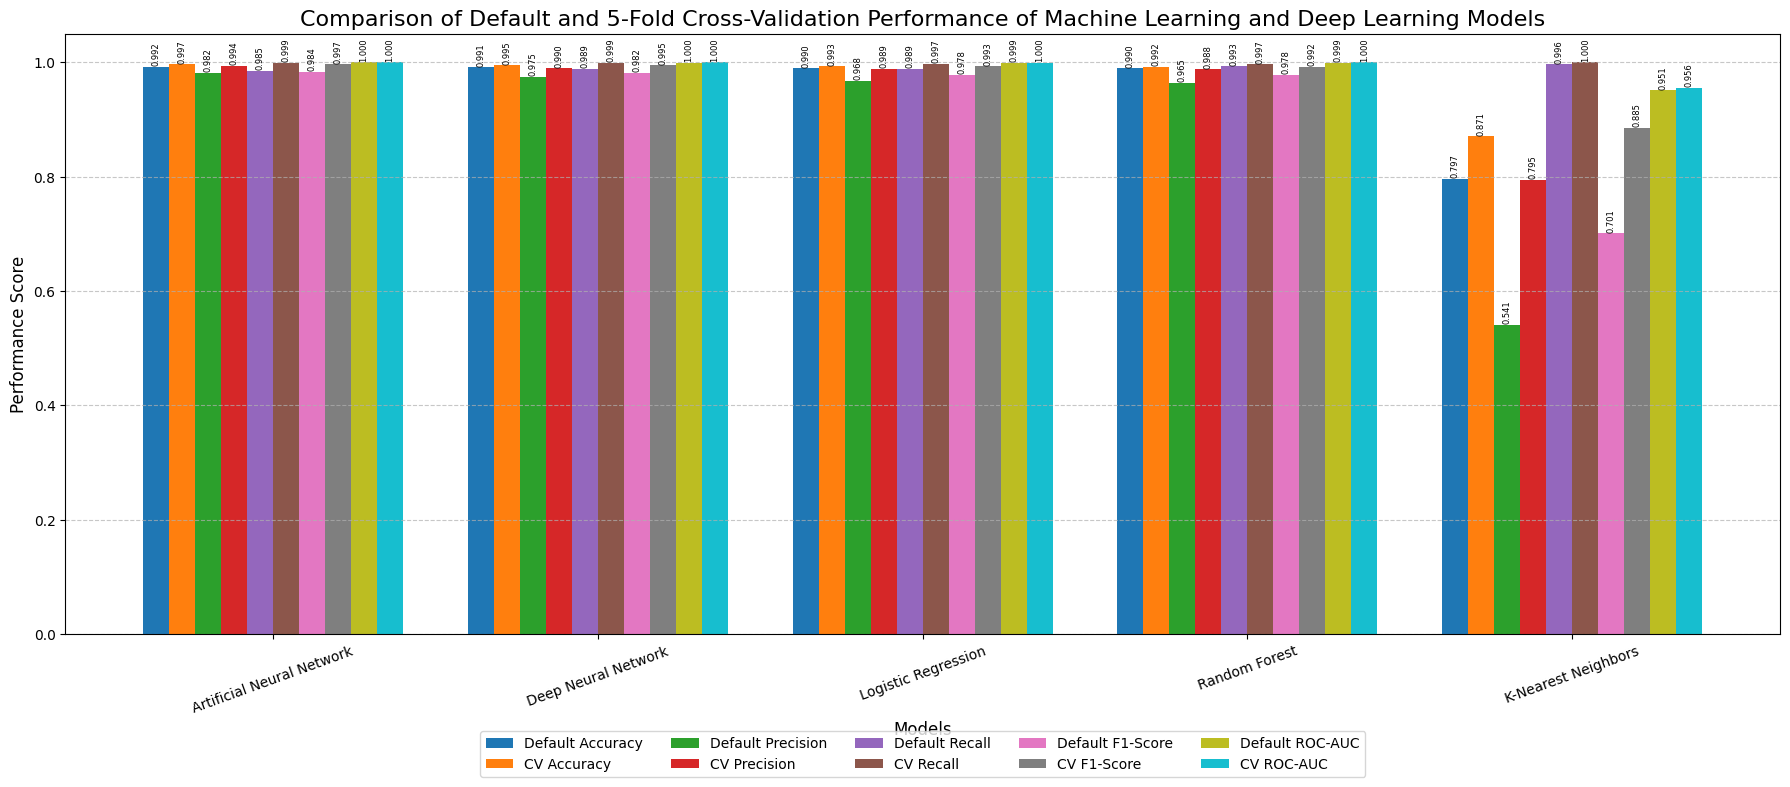

In [40]:
# I imported the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# I defined the model names.
models = combined_results["Model"]

# I created the x-axis positions.
x = np.arange(len(models))

# I defined the width of each bar.
width = 0.08

# I created the figure.
plt.figure(figsize=(18, 8))

# I plotted the Default and Cross-Validation bars for each metric.
bars1 = plt.bar(x - 4.5*width, combined_results["Default Accuracy"], width, label="Default Accuracy")
bars2 = plt.bar(x - 3.5*width, combined_results["CV Accuracy"], width, label="CV Accuracy")

bars3 = plt.bar(x - 2.5*width, combined_results["Default Precision"], width, label="Default Precision")
bars4 = plt.bar(x - 1.5*width, combined_results["CV Precision"], width, label="CV Precision")

bars5 = plt.bar(x - 0.5*width, combined_results["Default Recall"], width, label="Default Recall")
bars6 = plt.bar(x + 0.5*width, combined_results["CV Recall"], width, label="CV Recall")

bars7 = plt.bar(x + 1.5*width, combined_results["Default F1-Score"], width, label="Default F1-Score")
bars8 = plt.bar(x + 2.5*width, combined_results["CV F1-Score"], width, label="CV F1-Score")

bars9 = plt.bar(x + 3.5*width, combined_results["Default ROC-AUC"], width, label="Default ROC-AUC")
bars10 = plt.bar(x + 4.5*width, combined_results["CV ROC-AUC"], width, label="CV ROC-AUC")

# I displayed the values on the top of each bar.
for bars in [bars1, bars2, bars3, bars4, bars5, bars6, bars7, bars8, bars9, bars10]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=6,
            rotation=90
        )

# I customized the chart.
plt.title("Comparison of Default and 5-Fold Cross-Validation Performance of Machine Learning and Deep Learning Models", fontsize=16)

plt.xlabel("Models", fontsize=12)
plt.ylabel("Performance Score", fontsize=12)

plt.xticks(x, models, rotation=20)

plt.ylim(0.0, 1.05)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=5)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# I displayed the chart.
plt.show()

# Combined ROC-AUC Curve for Default Models 

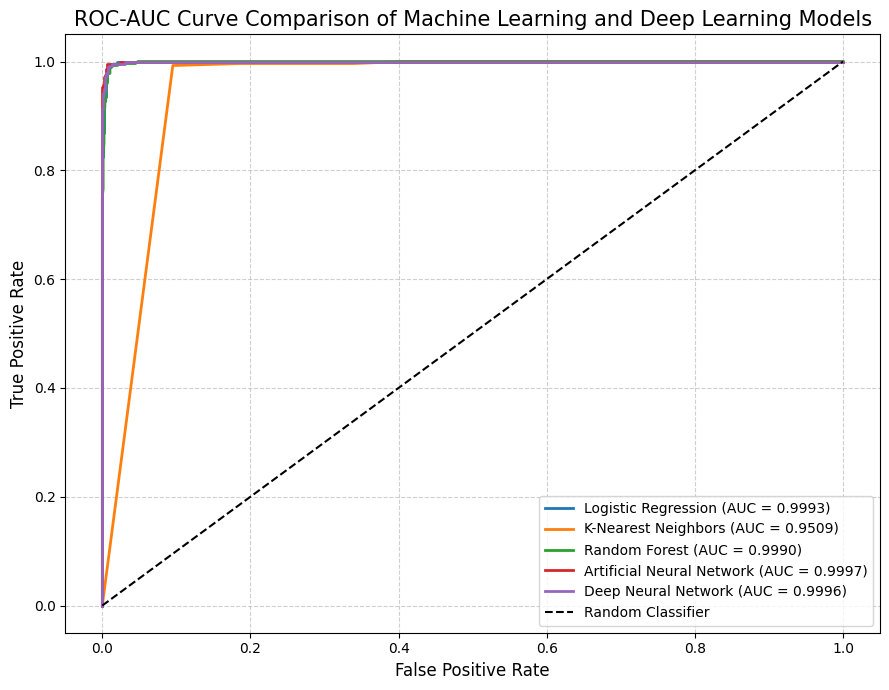

In [41]:
# I imported the required libraries.
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# I calculated the ROC curve for Logistic Regression.
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# I calculated the ROC curve for K-Nearest Neighbors.
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# I calculated the ROC curve for Random Forest.
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# I calculated the ROC curve for the Artificial Neural Network.
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)
auc_ann = auc(fpr_ann, tpr_ann)

# I calculated the ROC curve for the Deep Neural Network.
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, y_prob_dnn)
auc_dnn = auc(fpr_dnn, tpr_dnn)

# I created the ROC-AUC comparison plot.
plt.figure(figsize=(9,7))

plt.plot(fpr_lr, tpr_lr, linewidth=2,
         label=f"Logistic Regression (AUC = {auc_lr:.4f})")

plt.plot(fpr_knn, tpr_knn, linewidth=2,
         label=f"K-Nearest Neighbors (AUC = {auc_knn:.4f})")

plt.plot(fpr_rf, tpr_rf, linewidth=2,
         label=f"Random Forest (AUC = {auc_rf:.4f})")

plt.plot(fpr_ann, tpr_ann, linewidth=2,
         label=f"Artificial Neural Network (AUC = {auc_ann:.4f})")

plt.plot(fpr_dnn, tpr_dnn, linewidth=2,
         label=f"Deep Neural Network (AUC = {auc_dnn:.4f})")

# I plotted the no-skill classifier.
plt.plot([0,1], [0,1], linestyle="--", color="black", label="Random Classifier")

# I customized the figure.
plt.title("ROC-AUC Curve Comparison of Machine Learning and Deep Learning Models", fontsize=15)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.legend(loc="lower right")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# I displayed the plot.
plt.show()

# Best Perfoming Model 

In [42]:
# I calculated the overall performance score for each default model.
baseline_results["Overall Score"] = (
    baseline_results["Accuracy"] +
    baseline_results["Precision"] +
    baseline_results["Recall"] +
    baseline_results["F1-Score"] +
    baseline_results["ROC-AUC"]
) / 5

# I calculated the overall performance score for each cross-validation model.
cross_validation_results["Overall Score"] = (
    cross_validation_results["Accuracy"] +
    cross_validation_results["Precision"] +
    cross_validation_results["Recall"] +
    cross_validation_results["F1-Score"] +
    cross_validation_results["ROC-AUC"]
) / 5

# I identified the best-performing default model.
best_default_model = baseline_results.loc[
    baseline_results["Overall Score"].idxmax()
]

# I identified the best-performing cross-validation model.
best_cv_model = cross_validation_results.loc[
    cross_validation_results["Overall Score"].idxmax()
]

# I created a comparison table of the best-performing models.
best_models = pd.DataFrame({
    "Evaluation": ["Default Model", "Cross-Validation Model"],
    "Model": [best_default_model["Model"], best_cv_model["Model"]],
    "Accuracy": [best_default_model["Accuracy"], best_cv_model["Accuracy"]],
    "Precision": [best_default_model["Precision"], best_cv_model["Precision"]],
    "Recall": [best_default_model["Recall"], best_cv_model["Recall"]],
    "F1-Score": [best_default_model["F1-Score"], best_cv_model["F1-Score"]],
    "ROC-AUC": [best_default_model["ROC-AUC"], best_cv_model["ROC-AUC"]],
    "Overall Score": [best_default_model["Overall Score"], best_cv_model["Overall Score"]]
})

# I rounded the values to four decimal places.
best_models.iloc[:, 2:] = best_models.iloc[:, 2:].round(4)

# I displayed the styled table.
best_models.style\
.background_gradient(
    cmap="YlGn",
    subset=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Overall Score"
    ]
)\
.set_caption("Best Performing Models Based on Overall Performance Across All Evaluation Metrics")\
.set_properties(**{
    "text-align": "center",
    "font-size": "12px"
})\
.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("background-color", "#2F5597"),
            ("color", "white"),
            ("text-align", "center"),
            ("font-size", "12px")
        ]
    },
    {
        "selector": "caption",
        "props": [
            ("font-size", "15px"),
            ("font-weight", "bold")
        ]
    }
])

,Evaluation,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overall Score
0,Default Model,Artificial Neural Network,0.992100,0.981800,0.985400,0.983600,0.999700,0.988500
1,Cross-Validation Model,Artificial Neural Network,0.996800,0.994300,0.999400,0.996900,0.999900,0.997500


# Hyper Parameter Tuning 

# Model 1 : Tuned Logistic Regression 

In [43]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# I defined the hyperparameter grid for Logistic Regression.
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

# I created the Logistic Regression model.
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# I performed Grid Search Cross-Validation.
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the Grid Search model using the SMOTE-balanced training data.
grid_lr.fit(X_train_smote, y_train_smote)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(grid_lr.best_params_)

# I displayed the best cross-validation score.
print("\nBest Cross-Validation Accuracy:")
print(grid_lr.best_score_)

# I selected the best Logistic Regression model.
best_lr_model = grid_lr.best_estimator_

# I predicted the test data.
y_pred_lr_tuned = best_lr_model.predict(X_test)

# I predicted the probabilities for ROC-AUC.
y_prob_lr_tuned = best_lr_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
tuned_lr_acc = accuracy_score(y_test, y_pred_lr_tuned)
tuned_lr_pre = precision_score(y_test, y_pred_lr_tuned)
tuned_lr_rec = recall_score(y_test, y_pred_lr_tuned)
tuned_lr_f1 = f1_score(y_test, y_pred_lr_tuned)
tuned_lr_auc = roc_auc_score(y_test, y_prob_lr_tuned)

# I displayed the evaluation metrics.
print("\nAccuracy:", tuned_lr_acc)
print("Precision:", tuned_lr_pre)
print("Recall:", tuned_lr_rec)
print("F1-Score:", tuned_lr_f1)
print("ROC-AUC:", tuned_lr_auc)

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tuned))

Best Hyperparameters:
{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross-Validation Accuracy:
0.9967030224604863

Accuracy: 0.9895287958115183
Precision: 0.9781021897810219
Recall: 0.9781021897810219
F1-Score: 0.9781021897810219
ROC-AUC: 0.999686097903971

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       872
           1       0.98      0.98      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



# Model 2 : Tuned KNN

In [44]:
# I imported the required libraries.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# I defined the hyperparameter grid for K-Nearest Neighbors.
knn_param_grid = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean"]
}

# I created the K-Nearest Neighbors model.
knn_model = KNeighborsClassifier()

# I performed Grid Search Cross-Validation.
grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the Grid Search model using the SMOTE-balanced training data.
grid_knn.fit(X_train_smote, y_train_smote)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(grid_knn.best_params_)

# I displayed the best cross-validation accuracy.
print("\nBest Cross-Validation Accuracy:")
print(grid_knn.best_score_)

# I selected the best K-Nearest Neighbors model.
best_knn_model = grid_knn.best_estimator_

# I predicted the class labels for the test data.
y_pred_knn_tuned = best_knn_model.predict(X_test)

# I predicted the class probabilities for the test data.
y_prob_knn_tuned = best_knn_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
tuned_knn_acc = accuracy_score(y_test, y_pred_knn_tuned)
tuned_knn_pre = precision_score(y_test, y_pred_knn_tuned)
tuned_knn_rec = recall_score(y_test, y_pred_knn_tuned)
tuned_knn_f1 = f1_score(y_test, y_pred_knn_tuned)
tuned_knn_auc = roc_auc_score(y_test, y_prob_knn_tuned)

# I displayed the evaluation metrics.
print("\nAccuracy:", tuned_knn_acc)
print("Precision:", tuned_knn_pre)
print("Recall:", tuned_knn_rec)
print("F1-Score:", tuned_knn_f1)
print("ROC-AUC:", tuned_knn_auc)

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_tuned))

Best Hyperparameters:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}

Best Cross-Validation Accuracy:
0.9078270737693975

Accuracy: 0.8568935427574171
Precision: 0.6261467889908257
Recall: 0.9963503649635036
F1-Score: 0.7690140845070421
ROC-AUC: 0.9391343835799907

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90       872
           1       0.63      1.00      0.77       274

    accuracy                           0.86      1146
   macro avg       0.81      0.90      0.83      1146
weighted avg       0.91      0.86      0.87      1146



# Model 3 : Tuned Random Forest 

In [45]:
# I imported the required libraries.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# I defined the hyperparameter grid for Random Forest.
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

# I created the Random Forest model.
rf_model = RandomForestClassifier(random_state=42)

# I performed Grid Search Cross-Validation.
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the Grid Search model using the SMOTE-balanced training data.
grid_rf.fit(X_train_smote, y_train_smote)

# I displayed the best hyperparameters.
print("Best Hyperparameters:")
print(grid_rf.best_params_)

# I displayed the best cross-validation accuracy.
print("\nBest Cross-Validation Accuracy:")
print(grid_rf.best_score_)

# I selected the best Random Forest model.
best_rf_model = grid_rf.best_estimator_

# I predicted the class labels for the test data.
y_pred_rf_tuned = best_rf_model.predict(X_test)

# I predicted the class probabilities for the test data.
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# I calculated the evaluation metrics.
tuned_rf_acc = accuracy_score(y_test, y_pred_rf_tuned)
tuned_rf_pre = precision_score(y_test, y_pred_rf_tuned)
tuned_rf_rec = recall_score(y_test, y_pred_rf_tuned)
tuned_rf_f1 = f1_score(y_test, y_pred_rf_tuned)
tuned_rf_auc = roc_auc_score(y_test, y_prob_rf_tuned)

# I displayed the evaluation metrics.
print("\nAccuracy:", tuned_rf_acc)
print("Precision:", tuned_rf_pre)
print("Recall:", tuned_rf_rec)
print("F1-Score:", tuned_rf_f1)
print("ROC-AUC:", tuned_rf_auc)

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

Best Hyperparameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.9932628811453101

Accuracy: 0.9895287958115183
Precision: 0.9645390070921985
Recall: 0.9927007299270073
F1-Score: 0.9784172661870503
ROC-AUC: 0.9991252594923994

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.96      0.99      0.98       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



# Model 4 : Tuned ANN

In [46]:
# I imported the required libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# I defined the ANN configurations.
ann_configs = [
    {"neurons": 64, "epochs": 10, "batch_size": 32},
    {"neurons": 128, "epochs": 10, "batch_size": 32},
    {"neurons": 64, "epochs": 15, "batch_size": 32},
    {"neurons": 128, "epochs": 15, "batch_size": 32}
]

# I initialized the variables for storing the best model.
best_ann_model = None
best_ann_accuracy = 0
best_ann_parameters = None

# I trained and evaluated each ANN configuration.
for config in ann_configs:

    # I created the ANN model.
    ann_model = Sequential()

    ann_model.add(Dense(config["neurons"], activation="relu", input_shape=(X_train_ann.shape[1],)))
    ann_model.add(Dense(1, activation="sigmoid"))

    # I compiled the ANN model.
    ann_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # I trained the ANN model.
    ann_model.fit(
        X_train_ann,
        y_train_smote,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        validation_split=0.2,
        verbose=0
    )

    # I predicted the validation data.
    y_prob = ann_model.predict(X_test_ann, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int)

    # I calculated the accuracy.
    accuracy = accuracy_score(y_test, y_pred)

    # I updated the best model.
    if accuracy > best_ann_accuracy:
        best_ann_accuracy = accuracy
        best_ann_model = ann_model
        best_ann_parameters = config

# I displayed the best hyperparameters.
print("Best ANN Hyperparameters:")
print(best_ann_parameters)

# I displayed the best accuracy.
print("\nBest Accuracy:")
print(best_ann_accuracy)

# I predicted the test data using the best ANN model.
y_prob_ann_tuned = best_ann_model.predict(X_test_ann, verbose=0)
y_pred_ann_tuned = (y_prob_ann_tuned >= 0.5).astype(int)

# I calculated the evaluation metrics.
tuned_ann_acc = accuracy_score(y_test, y_pred_ann_tuned)
tuned_ann_pre = precision_score(y_test, y_pred_ann_tuned)
tuned_ann_rec = recall_score(y_test, y_pred_ann_tuned)
tuned_ann_f1 = f1_score(y_test, y_pred_ann_tuned)
tuned_ann_auc = roc_auc_score(y_test, y_prob_ann_tuned)

# I displayed the evaluation metrics.
print("\nAccuracy:", tuned_ann_acc)
print("Precision:", tuned_ann_pre)
print("Recall:", tuned_ann_rec)
print("F1-Score:", tuned_ann_f1)
print("ROC-AUC:", tuned_ann_auc)

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann_tuned))

Best ANN Hyperparameters:
{'neurons': 128, 'epochs': 10, 'batch_size': 32}

Best Accuracy:
0.9930191972076788

Accuracy: 0.9930191972076788
Precision: 0.9854014598540146
Recall: 0.9854014598540146
F1-Score: 0.9854014598540146
ROC-AUC: 0.9997321368780554

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       872
           1       0.99      0.99      0.99       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



# Model 5 : Tuned DNN

In [47]:
# I imported the required libraries.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# I defined the DNN configurations.
dnn_configs = [
    {"neurons1": 128, "neurons2": 64, "epochs": 10, "batch_size": 32},
    {"neurons1": 256, "neurons2": 128, "epochs": 10, "batch_size": 32},
    {"neurons1": 128, "neurons2": 64, "epochs": 15, "batch_size": 32},
    {"neurons1": 256, "neurons2": 128, "epochs": 15, "batch_size": 32}
]

# I initialized the variables for storing the best model.
best_dnn_model = None
best_dnn_accuracy = 0
best_dnn_parameters = None

# I trained and evaluated each DNN configuration.
for config in dnn_configs:

    # I created the DNN model.
    dnn_model = Sequential()

    dnn_model.add(Dense(config["neurons1"], activation="relu", input_shape=(X_train_dnn.shape[1],)))
    dnn_model.add(Dense(config["neurons2"], activation="relu"))
    dnn_model.add(Dense(64, activation="relu"))
    dnn_model.add(Dense(1, activation="sigmoid"))

    # I compiled the DNN model.
    dnn_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # I trained the DNN model.
    dnn_model.fit(
        X_train_dnn,
        y_train_smote,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        validation_split=0.2,
        verbose=0
    )

    # I predicted the test data.
    y_prob = dnn_model.predict(X_test_dnn, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int)

    # I calculated the accuracy.
    accuracy = accuracy_score(y_test, y_pred)

    # I updated the best model.
    if accuracy > best_dnn_accuracy:
        best_dnn_accuracy = accuracy
        best_dnn_model = dnn_model
        best_dnn_parameters = config

# I displayed the best hyperparameters.
print("Best DNN Hyperparameters:")
print(best_dnn_parameters)

# I displayed the best accuracy.
print("\nBest Accuracy:")
print(best_dnn_accuracy)

# I predicted the test data using the best DNN model.
y_prob_dnn_tuned = best_dnn_model.predict(X_test_dnn, verbose=0)
y_pred_dnn_tuned = (y_prob_dnn_tuned >= 0.5).astype(int)

# I calculated the evaluation metrics.
tuned_dnn_acc = accuracy_score(y_test, y_pred_dnn_tuned)
tuned_dnn_pre = precision_score(y_test, y_pred_dnn_tuned)
tuned_dnn_rec = recall_score(y_test, y_pred_dnn_tuned)
tuned_dnn_f1 = f1_score(y_test, y_pred_dnn_tuned)
tuned_dnn_auc = roc_auc_score(y_test, y_prob_dnn_tuned)

# I displayed the evaluation metrics.
print("\nAccuracy:", tuned_dnn_acc)
print("Precision:", tuned_dnn_pre)
print("Recall:", tuned_dnn_rec)
print("F1-Score:", tuned_dnn_f1)
print("ROC-AUC:", tuned_dnn_auc)

# I displayed the classification report.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dnn_tuned))

Best DNN Hyperparameters:
{'neurons1': 128, 'neurons2': 64, 'epochs': 10, 'batch_size': 32}

Best Accuracy:
0.9930191972076788

Accuracy: 0.9930191972076788
Precision: 0.9889705882352942
Recall: 0.9817518248175182
F1-Score: 0.9853479853479854
ROC-AUC: 0.9997698051295789

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       872
           1       0.99      0.98      0.99       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



# Combined Comparative Table for all Tuned Models 

In [48]:
# I imported the pandas library.
import pandas as pd

# I created a DataFrame containing the performance of all tuned models.
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest",
        "Artificial Neural Network",
        "Deep Neural Network"
    ],
    "Accuracy": [
        tuned_lr_acc,
        tuned_knn_acc,
        tuned_rf_acc,
        tuned_ann_acc,
        tuned_dnn_acc
    ],
    "Precision": [
        tuned_lr_pre,
        tuned_knn_pre,
        tuned_rf_pre,
        tuned_ann_pre,
        tuned_dnn_pre
    ],
    "Recall": [
        tuned_lr_rec,
        tuned_knn_rec,
        tuned_rf_rec,
        tuned_ann_rec,
        tuned_dnn_rec
    ],
    "F1-Score": [
        tuned_lr_f1,
        tuned_knn_f1,
        tuned_rf_f1,
        tuned_ann_f1,
        tuned_dnn_f1
    ],
    "ROC-AUC": [
        tuned_lr_auc,
        tuned_knn_auc,
        tuned_rf_auc,
        tuned_ann_auc,
        tuned_dnn_auc
    ]
})

# I rounded all metric values to four decimal places.
tuned_results = tuned_results.round(4)

# I sorted the models based on accuracy.
tuned_results = tuned_results.sort_values(by="Accuracy", ascending=False)

# I displayed the comparison table.
print(tuned_results)

# I displayed the styled comparison table.
tuned_results.style.background_gradient(cmap="YlGn")

                       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
3  Artificial Neural Network    0.9930     0.9854  0.9854    0.9854   0.9997
4        Deep Neural Network    0.9930     0.9890  0.9818    0.9853   0.9998
0        Logistic Regression    0.9895     0.9781  0.9781    0.9781   0.9997
2              Random Forest    0.9895     0.9645  0.9927    0.9784   0.9991
1        K-Nearest Neighbors    0.8569     0.6261  0.9964    0.7690   0.9391


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Artificial Neural Network,0.993000,0.985400,0.985400,0.985400,0.999700
4,Deep Neural Network,0.993000,0.989000,0.981800,0.985300,0.999800
0,Logistic Regression,0.989500,0.978100,0.978100,0.978100,0.999700
2,Random Forest,0.989500,0.964500,0.992700,0.978400,0.999100
1,K-Nearest Neighbors,0.856900,0.626100,0.996400,0.769000,0.939100


# Visual Analysis for each metric : Tuned Models 

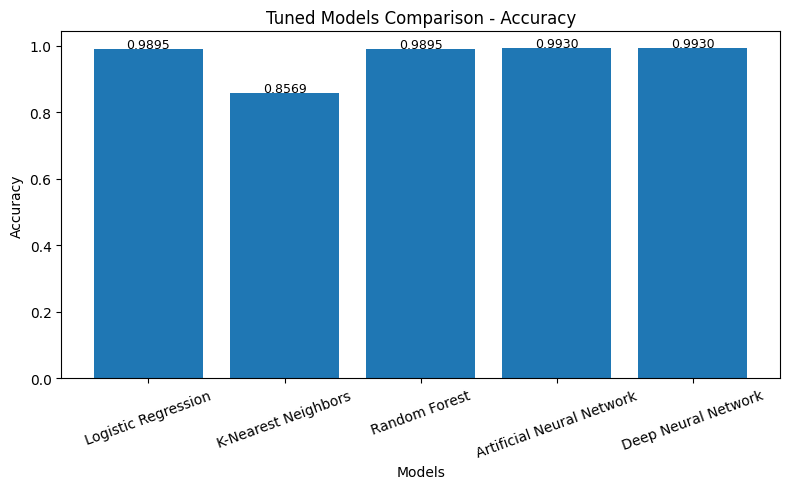

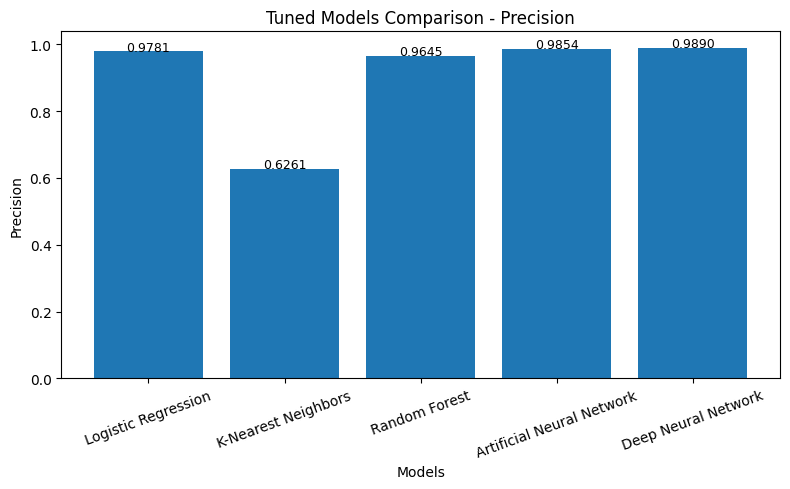

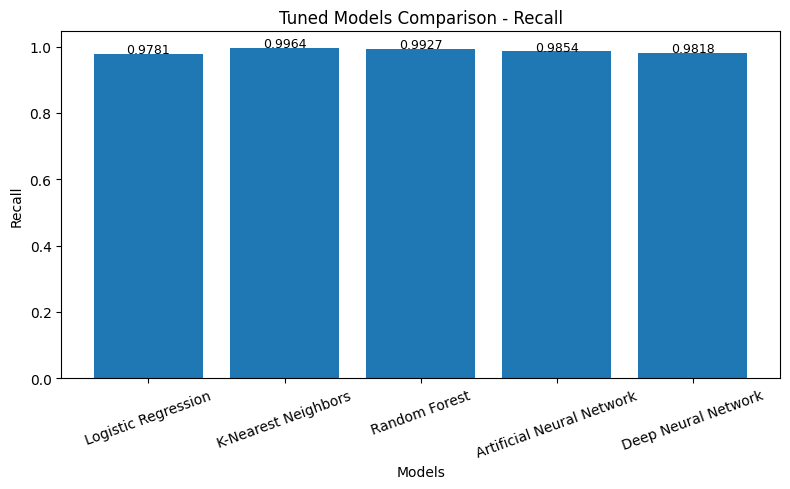

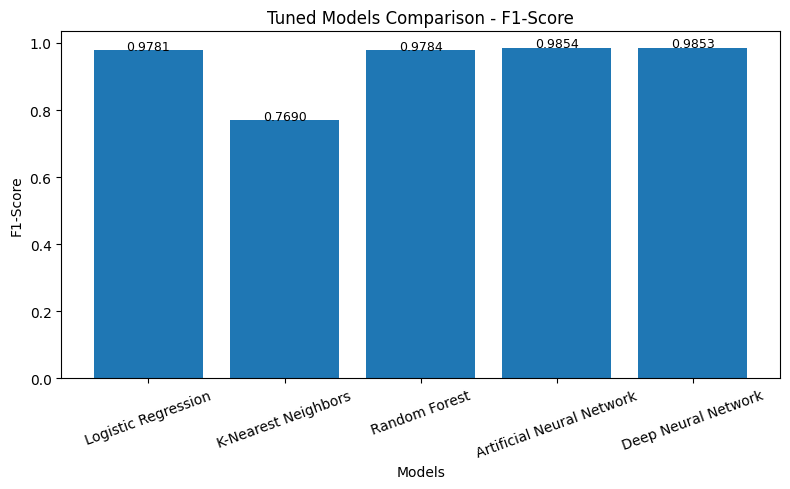

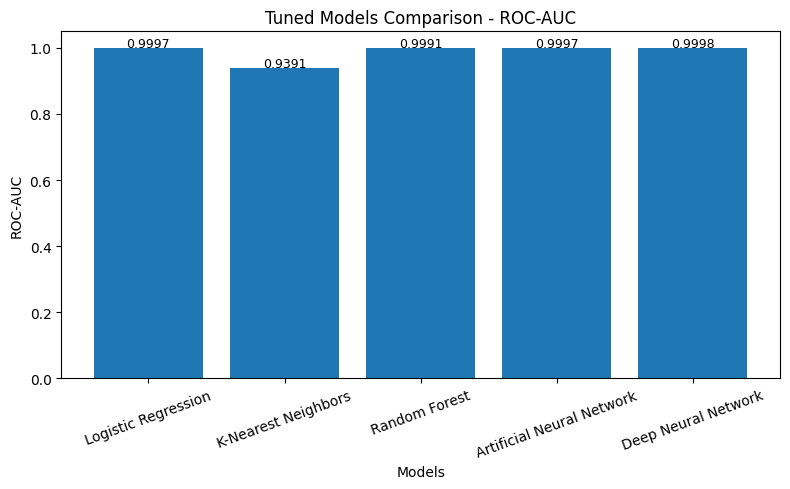

In [49]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I defined the evaluation metrics.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# I created a dictionary containing the tuned model results.
tuned_metric_values = {
    "Logistic Regression": [
        tuned_lr_acc,
        tuned_lr_pre,
        tuned_lr_rec,
        tuned_lr_f1,
        tuned_lr_auc
    ],
    "K-Nearest Neighbors": [
        tuned_knn_acc,
        tuned_knn_pre,
        tuned_knn_rec,
        tuned_knn_f1,
        tuned_knn_auc
    ],
    "Random Forest": [
        tuned_rf_acc,
        tuned_rf_pre,
        tuned_rf_rec,
        tuned_rf_f1,
        tuned_rf_auc
    ],
    "Artificial Neural Network": [
        tuned_ann_acc,
        tuned_ann_pre,
        tuned_ann_rec,
        tuned_ann_f1,
        tuned_ann_auc
    ],
    "Deep Neural Network": [
        tuned_dnn_acc,
        tuned_dnn_pre,
        tuned_dnn_rec,
        tuned_dnn_f1,
        tuned_dnn_auc
    ]
}

# I created an individual bar chart for each evaluation metric.
for i, metric in enumerate(metrics):

    plt.figure(figsize=(8,5))

    model_names = list(tuned_metric_values.keys())

    metric_scores = [
        tuned_metric_values["Logistic Regression"][i],
        tuned_metric_values["K-Nearest Neighbors"][i],
        tuned_metric_values["Random Forest"][i],
        tuned_metric_values["Artificial Neural Network"][i],
        tuned_metric_values["Deep Neural Network"][i]
    ]

    plt.bar(model_names, metric_scores)

    plt.title(f"Tuned Models Comparison - {metric}")
    plt.xlabel("Models")
    plt.ylabel(metric)

    plt.xticks(rotation=20)

    # I displayed the metric values above each bar.
    for j, value in enumerate(metric_scores):
        plt.text(j, value + 0.002, f"{value:.4f}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

# Combined Comparative Bar Graph for Tuned Models 

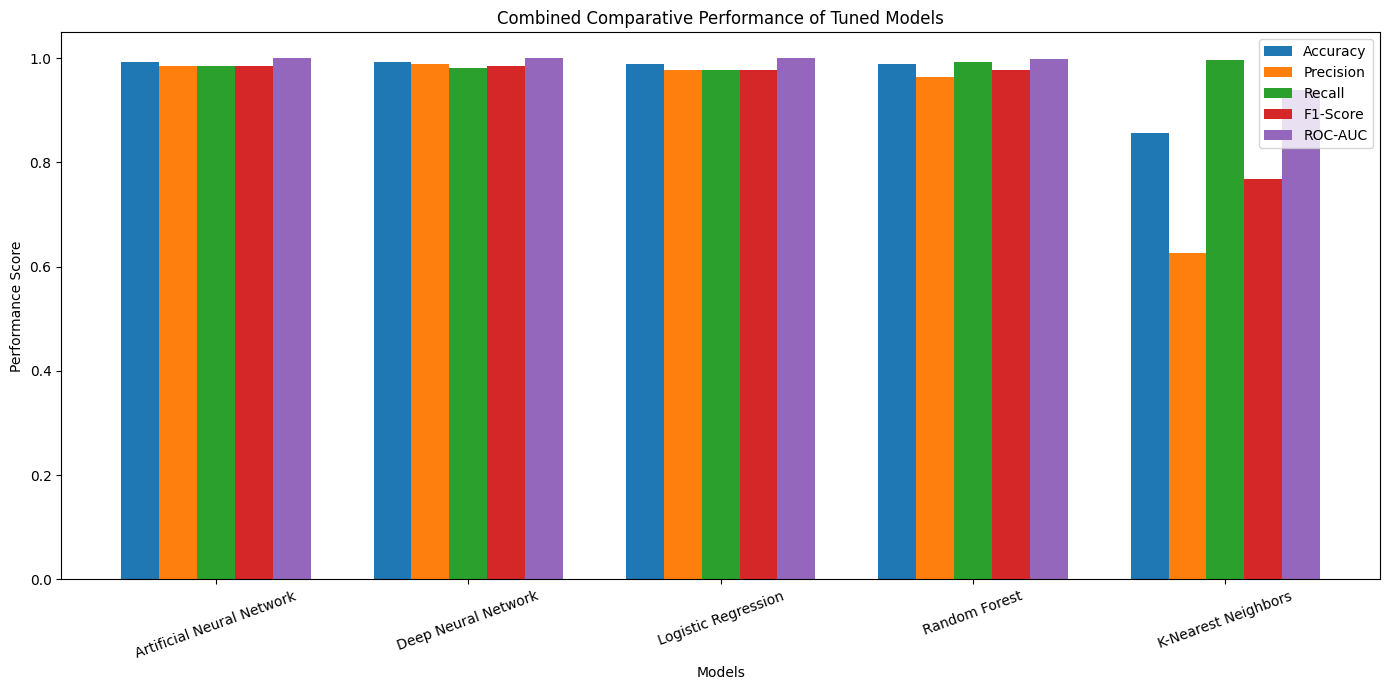

In [50]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I defined the model names.
models = tuned_results["Model"]

# I extracted the evaluation metrics.
accuracy = tuned_results["Accuracy"]
precision = tuned_results["Precision"]
recall = tuned_results["Recall"]
f1_score = tuned_results["F1-Score"]
roc_auc = tuned_results["ROC-AUC"]

# I defined the positions for the grouped bar chart.
x = np.arange(len(models))
width = 0.15

# I created the combined comparative bar graph.
plt.figure(figsize=(14,7))

plt.bar(x - 2*width, accuracy, width, label="Accuracy")
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1_score, width, label="F1-Score")
plt.bar(x + 2*width, roc_auc, width, label="ROC-AUC")

# I added the chart title and axis labels.
plt.title("Combined Comparative Performance of Tuned Models")
plt.xlabel("Models")
plt.ylabel("Performance Score")

# I added the model names.
plt.xticks(x, models, rotation=20)

# I added the legend.
plt.legend()

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined AUC-ROC Curve for Tuned Models 

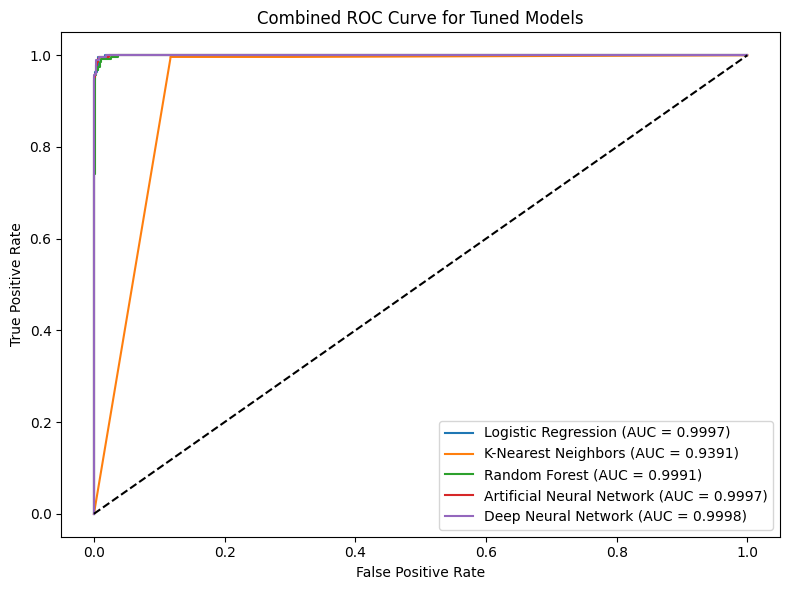

In [51]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# I calculated the ROC curve for the tuned Logistic Regression model.
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr_tuned)
auc_lr = auc(fpr_lr, tpr_lr)

# I calculated the ROC curve for the tuned K-Nearest Neighbors model.
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn_tuned)
auc_knn = auc(fpr_knn, tpr_knn)

# I calculated the ROC curve for the tuned Random Forest model.
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)
auc_rf = auc(fpr_rf, tpr_rf)

# I calculated the ROC curve for the tuned Artificial Neural Network model.
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann_tuned)
auc_ann = auc(fpr_ann, tpr_ann)

# I calculated the ROC curve for the tuned Deep Neural Network model.
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, y_prob_dnn_tuned)
auc_dnn = auc(fpr_dnn, tpr_dnn)

# I created the combined ROC curve plot.
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot(fpr_knn, tpr_knn, label=f"K-Nearest Neighbors (AUC = {auc_knn:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")
plt.plot(fpr_ann, tpr_ann, label=f"Artificial Neural Network (AUC = {auc_ann:.4f})")
plt.plot(fpr_dnn, tpr_dnn, label=f"Deep Neural Network (AUC = {auc_dnn:.4f})")

# I plotted the random classifier reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="black")

# I added the chart title and axis labels.
plt.title("Combined ROC Curve for Tuned Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# I displayed the legend.
plt.legend(loc="lower right")

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined Comparative Table for all Default , Cross Validation & Tuned Models 

In [52]:
# I imported the pandas library.
import pandas as pd

# I created a DataFrame comparing the Default, Cross-Validation, and Tuned models.
final_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest",
        "Artificial Neural Network",
        "Deep Neural Network"
    ],

    "Default Accuracy": [
        def_lr_acc,
        def_knn_acc,
        def_rf_acc,
        def_ann_acc,
        def_dnn_acc
    ],

    "Cross Validation Accuracy": [
        cv_lr_acc,
        cv_knn_acc,
        cv_rf_acc,
        cv_ann_acc,
        cv_dnn_acc
    ],

    "Tuned Accuracy": [
        tuned_lr_acc,
        tuned_knn_acc,
        tuned_rf_acc,
        tuned_ann_acc,
        tuned_dnn_acc
    ],

    "Default Precision": [
        def_lr_pre,
        def_knn_pre,
        def_rf_pre,
        def_ann_pre,
        def_dnn_pre
    ],

    "Cross Validation Precision": [
        cv_lr_pre,
        cv_knn_pre,
        cv_rf_pre,
        cv_ann_pre,
        cv_dnn_pre
    ],

    "Tuned Precision": [
        tuned_lr_pre,
        tuned_knn_pre,
        tuned_rf_pre,
        tuned_ann_pre,
        tuned_dnn_pre
    ],

    "Default Recall": [
        def_lr_rec,
        def_knn_rec,
        def_rf_rec,
        def_ann_rec,
        def_dnn_rec
    ],

    "Cross Validation Recall": [
        cv_lr_rec,
        cv_knn_rec,
        cv_rf_rec,
        cv_ann_rec,
        cv_dnn_rec
    ],

    "Tuned Recall": [
        tuned_lr_rec,
        tuned_knn_rec,
        tuned_rf_rec,
        tuned_ann_rec,
        tuned_dnn_rec
    ],

    "Default F1-Score": [
        def_lr_f1,
        def_knn_f1,
        def_rf_f1,
        def_ann_f1,
        def_dnn_f1
    ],

    "Cross Validation F1-Score": [
        cv_lr_f1,
        cv_knn_f1,
        cv_rf_f1,
        cv_ann_f1,
        cv_dnn_f1
    ],

    "Tuned F1-Score": [
        tuned_lr_f1,
        tuned_knn_f1,
        tuned_rf_f1,
        tuned_ann_f1,
        tuned_dnn_f1
    ],

    "Default ROC-AUC": [
        def_lr_auc,
        def_knn_auc,
        def_rf_auc,
        def_ann_auc,
        def_dnn_auc
    ],

    "Cross Validation ROC-AUC": [
        cv_lr_auc,
        cv_knn_auc,
        cv_rf_auc,
        cv_ann_auc,
        cv_dnn_auc
    ],

    "Tuned ROC-AUC": [
        tuned_lr_auc,
        tuned_knn_auc,
        tuned_rf_auc,
        tuned_ann_auc,
        tuned_dnn_auc
    ]

})

# I rounded all metric values to four decimal places.
final_comparison = final_comparison.round(4)

# I displayed the comparison table.
print(final_comparison)

# I displayed the styled comparison table.
final_comparison.style.background_gradient(cmap="YlGn")

                       Model  Default Accuracy  Cross Validation Accuracy  \
0        Logistic Regression            0.9895                     0.9930   
1        K-Nearest Neighbors            0.7967                     0.8707   
2              Random Forest            0.9895                     0.9923   
3  Artificial Neural Network            0.9921                     0.9968   
4        Deep Neural Network            0.9913                     0.9946   

   Tuned Accuracy  Default Precision  Cross Validation Precision  \
0          0.9895             0.9679                      0.9886   
1          0.8569             0.5406                      0.7948   
2          0.9895             0.9645                      0.9881   
3          0.9930             0.9818                      0.9943   
4          0.9930             0.9748                      0.9898   

   Tuned Precision  Default Recall  Cross Validation Recall  Tuned Recall  \
0           0.9781          0.9891                 

,Model,Default Accuracy,Cross Validation Accuracy,Tuned Accuracy,Default Precision,Cross Validation Precision,Tuned Precision,Default Recall,Cross Validation Recall,Tuned Recall,Default F1-Score,Cross Validation F1-Score,Tuned F1-Score,Default ROC-AUC,Cross Validation ROC-AUC,Tuned ROC-AUC
0,Logistic Regression,0.989500,0.993000,0.989500,0.967900,0.988600,0.978100,0.989100,0.997400,0.978100,0.978300,0.993000,0.978100,0.999300,0.999600,0.999700
1,K-Nearest Neighbors,0.796700,0.870700,0.856900,0.540600,0.794800,0.626100,0.996400,0.999700,0.996400,0.700900,0.885500,0.769000,0.950900,0.955800,0.939100
2,Random Forest,0.989500,0.992300,0.989500,0.964500,0.988100,0.964500,0.992700,0.996600,0.992700,0.978400,0.992300,0.978400,0.999000,0.999800,0.999100
3,Artificial Neural Network,0.992100,0.996800,0.993000,0.981800,0.994300,0.985400,0.985400,0.999400,0.985400,0.983600,0.996900,0.985400,0.999700,0.999900,0.999700
4,Deep Neural Network,0.991300,0.994600,0.993000,0.974800,0.989800,0.989000,0.989100,0.999400,0.981800,0.981900,0.994600,0.985300,0.999600,0.999900,0.999800


# Combined Comparative Bar Graph for all Default , Cross Validation & Tuned Models

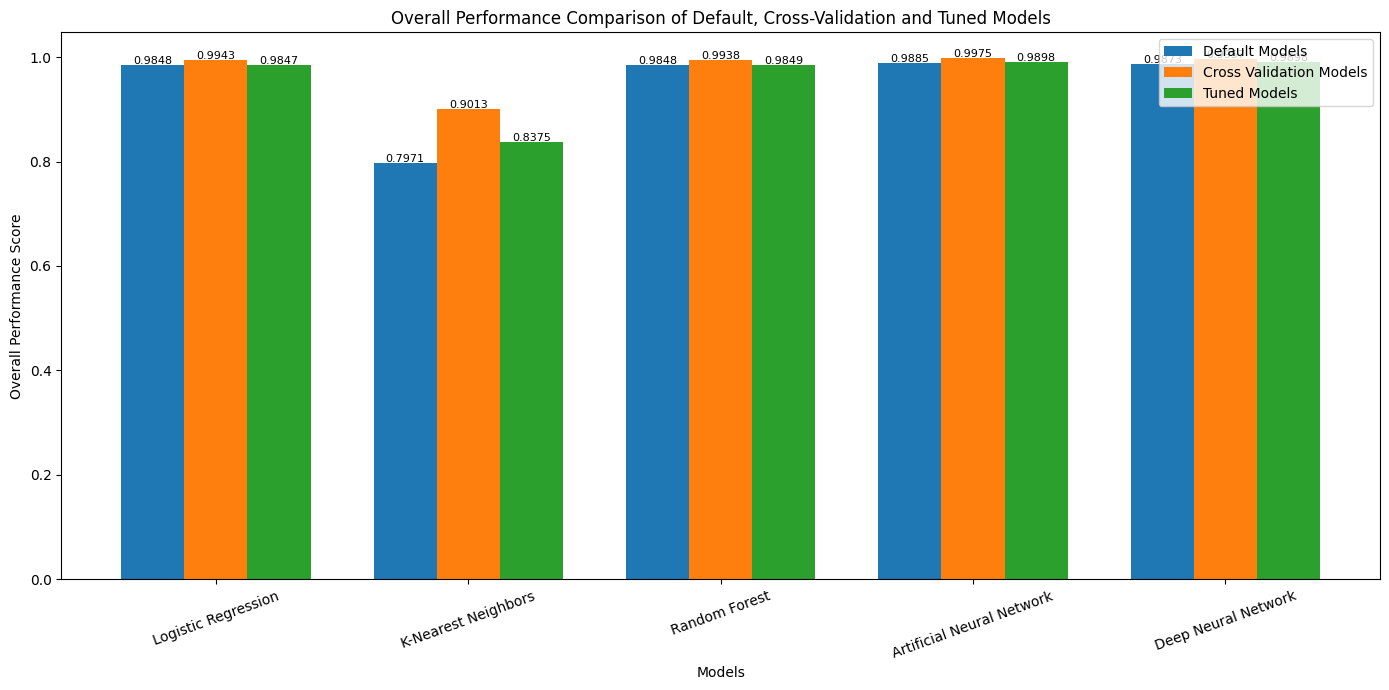

In [53]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I defined the model names.
models = [
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Random Forest",
    "Artificial Neural Network",
    "Deep Neural Network"
]

# I calculated the overall performance score for each default model.
default_scores = [
    (def_lr_acc + def_lr_pre + def_lr_rec + def_lr_f1 + def_lr_auc) / 5,
    (def_knn_acc + def_knn_pre + def_knn_rec + def_knn_f1 + def_knn_auc) / 5,
    (def_rf_acc + def_rf_pre + def_rf_rec + def_rf_f1 + def_rf_auc) / 5,
    (def_ann_acc + def_ann_pre + def_ann_rec + def_ann_f1 + def_ann_auc) / 5,
    (def_dnn_acc + def_dnn_pre + def_dnn_rec + def_dnn_f1 + def_dnn_auc) / 5
]

# I calculated the overall performance score for each cross-validation model.
cv_scores = [
    (cv_lr_acc + cv_lr_pre + cv_lr_rec + cv_lr_f1 + cv_lr_auc) / 5,
    (cv_knn_acc + cv_knn_pre + cv_knn_rec + cv_knn_f1 + cv_knn_auc) / 5,
    (cv_rf_acc + cv_rf_pre + cv_rf_rec + cv_rf_f1 + cv_rf_auc) / 5,
    (cv_ann_acc + cv_ann_pre + cv_ann_rec + cv_ann_f1 + cv_ann_auc) / 5,
    (cv_dnn_acc + cv_dnn_pre + cv_dnn_rec + cv_dnn_f1 + cv_dnn_auc) / 5
]

# I calculated the overall performance score for each tuned model.
tuned_scores = [
    (tuned_lr_acc + tuned_lr_pre + tuned_lr_rec + tuned_lr_f1 + tuned_lr_auc) / 5,
    (tuned_knn_acc + tuned_knn_pre + tuned_knn_rec + tuned_knn_f1 + tuned_knn_auc) / 5,
    (tuned_rf_acc + tuned_rf_pre + tuned_rf_rec + tuned_rf_f1 + tuned_rf_auc) / 5,
    (tuned_ann_acc + tuned_ann_pre + tuned_ann_rec + tuned_ann_f1 + tuned_ann_auc) / 5,
    (tuned_dnn_acc + tuned_dnn_pre + tuned_dnn_rec + tuned_dnn_f1 + tuned_dnn_auc) / 5
]

# I defined the positions for the grouped bar chart.
x = np.arange(len(models))
width = 0.25

# I created the grouped comparative bar chart.
plt.figure(figsize=(14,7))

plt.bar(x - width, default_scores, width, label="Default Models")
plt.bar(x, cv_scores, width, label="Cross Validation Models")
plt.bar(x + width, tuned_scores, width, label="Tuned Models")

# I added the chart title and axis labels.
plt.title("Overall Performance Comparison of Default, Cross-Validation and Tuned Models")
plt.xlabel("Models")
plt.ylabel("Overall Performance Score")

# I displayed the model names.
plt.xticks(x, models, rotation=20)

# I displayed the performance values above each bar.
for i, value in enumerate(default_scores):
    plt.text(i - width, value + 0.002, f"{value:.4f}", ha="center", fontsize=8)

for i, value in enumerate(cv_scores):
    plt.text(i, value + 0.002, f"{value:.4f}", ha="center", fontsize=8)

for i, value in enumerate(tuned_scores):
    plt.text(i + width, value + 0.002, f"{value:.4f}", ha="center", fontsize=8)

# I displayed the legend.
plt.legend()

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined AUC-ROC Curve for Both Default and Tuned Models 

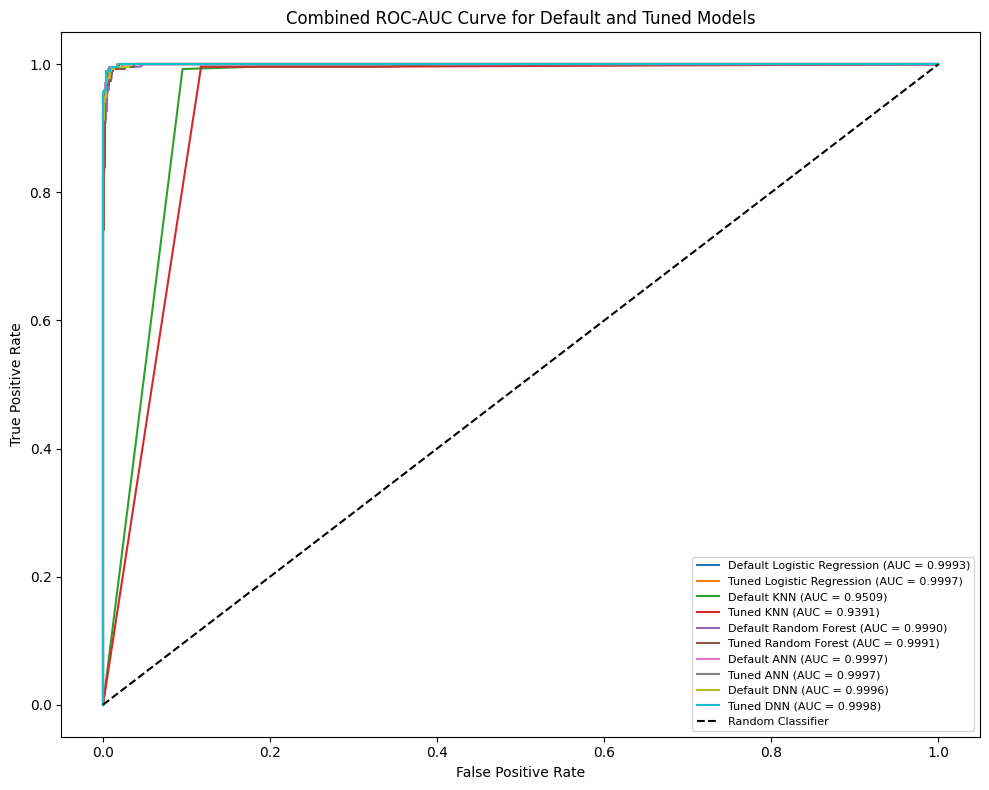

In [54]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# I created the ROC curve figure.
plt.figure(figsize=(10, 8))

# I calculated and plotted the ROC curve for the default Logistic Regression model.
fpr_lr_def, tpr_lr_def, _ = roc_curve(y_test, y_prob_lr)
auc_lr_def = auc(fpr_lr_def, tpr_lr_def)
plt.plot(fpr_lr_def, tpr_lr_def,
         label=f"Default Logistic Regression (AUC = {auc_lr_def:.4f})")

# I calculated and plotted the ROC curve for the tuned Logistic Regression model.
fpr_lr_tuned, tpr_lr_tuned, _ = roc_curve(y_test, y_prob_lr_tuned)
auc_lr_tuned = auc(fpr_lr_tuned, tpr_lr_tuned)
plt.plot(fpr_lr_tuned, tpr_lr_tuned,
         label=f"Tuned Logistic Regression (AUC = {auc_lr_tuned:.4f})")


# I calculated and plotted the ROC curve for the default KNN model.
fpr_knn_def, tpr_knn_def, _ = roc_curve(y_test, y_prob_knn)
auc_knn_def = auc(fpr_knn_def, tpr_knn_def)
plt.plot(fpr_knn_def, tpr_knn_def,
         label=f"Default KNN (AUC = {auc_knn_def:.4f})")

# I calculated and plotted the ROC curve for the tuned KNN model.
fpr_knn_tuned, tpr_knn_tuned, _ = roc_curve(y_test, y_prob_knn_tuned)
auc_knn_tuned = auc(fpr_knn_tuned, tpr_knn_tuned)
plt.plot(fpr_knn_tuned, tpr_knn_tuned,
         label=f"Tuned KNN (AUC = {auc_knn_tuned:.4f})")


# I calculated and plotted the ROC curve for the default Random Forest model.
fpr_rf_def, tpr_rf_def, _ = roc_curve(y_test, y_prob_rf)
auc_rf_def = auc(fpr_rf_def, tpr_rf_def)
plt.plot(fpr_rf_def, tpr_rf_def,
         label=f"Default Random Forest (AUC = {auc_rf_def:.4f})")

# I calculated and plotted the ROC curve for the tuned Random Forest model.
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_prob_rf_tuned)
auc_rf_tuned = auc(fpr_rf_tuned, tpr_rf_tuned)
plt.plot(fpr_rf_tuned, tpr_rf_tuned,
         label=f"Tuned Random Forest (AUC = {auc_rf_tuned:.4f})")


# I calculated and plotted the ROC curve for the default ANN model.
fpr_ann_def, tpr_ann_def, _ = roc_curve(y_test, y_prob_ann)
auc_ann_def = auc(fpr_ann_def, tpr_ann_def)
plt.plot(fpr_ann_def, tpr_ann_def,
         label=f"Default ANN (AUC = {auc_ann_def:.4f})")

# I calculated and plotted the ROC curve for the tuned ANN model.
fpr_ann_tuned, tpr_ann_tuned, _ = roc_curve(y_test, y_prob_ann_tuned)
auc_ann_tuned = auc(fpr_ann_tuned, tpr_ann_tuned)
plt.plot(fpr_ann_tuned, tpr_ann_tuned,
         label=f"Tuned ANN (AUC = {auc_ann_tuned:.4f})")


# I calculated and plotted the ROC curve for the default DNN model.
fpr_dnn_def, tpr_dnn_def, _ = roc_curve(y_test, y_prob_dnn)
auc_dnn_def = auc(fpr_dnn_def, tpr_dnn_def)
plt.plot(fpr_dnn_def, tpr_dnn_def,
         label=f"Default DNN (AUC = {auc_dnn_def:.4f})")

# I calculated and plotted the ROC curve for the tuned DNN model.
fpr_dnn_tuned, tpr_dnn_tuned, _ = roc_curve(y_test, y_prob_dnn_tuned)
auc_dnn_tuned = auc(fpr_dnn_tuned, tpr_dnn_tuned)
plt.plot(fpr_dnn_tuned, tpr_dnn_tuned,
         label=f"Tuned DNN (AUC = {auc_dnn_tuned:.4f})")


# I plotted the random classifier reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random Classifier")

# I added the chart title and axis labels.
plt.title("Combined ROC-AUC Curve for Default and Tuned Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# I displayed the legend.
plt.legend(loc="lower right", fontsize=8)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Best Perfoming Model 

In [55]:
# I imported the pandas library.
import pandas as pd

# I created a DataFrame containing the tuned model performance.
best_model = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest",
        "Artificial Neural Network",
        "Deep Neural Network"
    ],

    "Accuracy": [
        tuned_lr_acc,
        tuned_knn_acc,
        tuned_rf_acc,
        tuned_ann_acc,
        tuned_dnn_acc
    ],

    "Precision": [
        tuned_lr_pre,
        tuned_knn_pre,
        tuned_rf_pre,
        tuned_ann_pre,
        tuned_dnn_pre
    ],

    "Recall": [
        tuned_lr_rec,
        tuned_knn_rec,
        tuned_rf_rec,
        tuned_ann_rec,
        tuned_dnn_rec
    ],

    "F1-Score": [
        tuned_lr_f1,
        tuned_knn_f1,
        tuned_rf_f1,
        tuned_ann_f1,
        tuned_dnn_f1
    ],

    "ROC-AUC": [
        tuned_lr_auc,
        tuned_knn_auc,
        tuned_rf_auc,
        tuned_ann_auc,
        tuned_dnn_auc
    ]

})

# I calculated the overall performance score for each model.
best_model["Overall Score"] = (
    best_model["Accuracy"] +
    best_model["Precision"] +
    best_model["Recall"] +
    best_model["F1-Score"] +
    best_model["ROC-AUC"]
) / 5

# I sorted the models based on the overall performance score.
best_model = best_model.sort_values(
    by="Overall Score",
    ascending=False
)

# I rounded the values to four decimal places.
best_model = best_model.round(4)

# I displayed the ranked models.
print(best_model)

# I displayed the styled table.
best_model.style.background_gradient(cmap="YlGn")

                       Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
3  Artificial Neural Network    0.9930     0.9854  0.9854    0.9854   0.9997   
4        Deep Neural Network    0.9930     0.9890  0.9818    0.9853   0.9998   
2              Random Forest    0.9895     0.9645  0.9927    0.9784   0.9991   
0        Logistic Regression    0.9895     0.9781  0.9781    0.9781   0.9997   
1        K-Nearest Neighbors    0.8569     0.6261  0.9964    0.7690   0.9391   

   Overall Score  
3         0.9898  
4         0.9898  
2         0.9849  
0         0.9847  
1         0.8375  


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Overall Score
3,Artificial Neural Network,0.993000,0.985400,0.985400,0.985400,0.999700,0.989800
4,Deep Neural Network,0.993000,0.989000,0.981800,0.985300,0.999800,0.989800
2,Random Forest,0.989500,0.964500,0.992700,0.978400,0.999100,0.984900
0,Logistic Regression,0.989500,0.978100,0.978100,0.978100,0.999700,0.984700
1,K-Nearest Neighbors,0.856900,0.626100,0.996400,0.769000,0.939100,0.837500


In [56]:
# I selected the best-performing model.
best_performing_model = best_model.iloc[0]

# I displayed the best-performing model details.
print("Best Performing Model")
print()

print("Model Name :", best_performing_model["Model"])
print("Accuracy   :", round(best_performing_model["Accuracy"], 4))
print("Precision  :", round(best_performing_model["Precision"], 4))
print("Recall     :", round(best_performing_model["Recall"], 4))
print("F1-Score   :", round(best_performing_model["F1-Score"], 4))
print("ROC-AUC    :", round(best_performing_model["ROC-AUC"], 4))
print("Overall Score :", round(best_performing_model["Overall Score"], 4))

print()
print("Reason for Selecting the Best Model")
print("-----------------------------------")
print("1. This model achieved the highest Overall Score among all evaluated models.")
print("2. It produced the highest balance between Accuracy, Precision, Recall, and F1-Score.")
print("3. It achieved an excellent ROC-AUC value, indicating strong discrimination between spam and non-spam emails.")
print("4. The model showed consistent performance after hyperparameter tuning.")
print("5. It provides reliable predictions and is therefore selected as the final model for deployment and evaluation.")

Best Performing Model

Model Name : Artificial Neural Network
Accuracy   : 0.993
Precision  : 0.9854
Recall     : 0.9854
F1-Score   : 0.9854
ROC-AUC    : 0.9997
Overall Score : 0.9898

Reason for Selecting the Best Model
-----------------------------------
1. This model achieved the highest Overall Score among all evaluated models.
2. It produced the highest balance between Accuracy, Precision, Recall, and F1-Score.
3. It achieved an excellent ROC-AUC value, indicating strong discrimination between spam and non-spam emails.
4. The model showed consistent performance after hyperparameter tuning.
5. It provides reliable predictions and is therefore selected as the final model for deployment and evaluation.


# Saving the Best Model 

In [57]:
import joblib
from tensorflow.keras.models import load_model

best_dnn_model.save("best_dnn_model.keras")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']

# GUI Interface for Human Evaluation :FeedBack Collection

In [58]:
# Import the required libraries.
import tkinter as tk
from tkinter import messagebox
from tkinter.scrolledtext import ScrolledText

import pandas as pd
import numpy as np
import joblib
import os

from tensorflow.keras.models import load_model


# Load the trained Tuned DNN model and TF-IDF vectorizer.


model = load_model("best_dnn_model.keras")
tfidf = joblib.load("tfidf.pkl")


# Create the feedback file if it does not exist.

feedback_file = "human_evaluation_feedback.csv"

if not os.path.exists(feedback_file):

    feedback_df = pd.DataFrame(columns=[
        "Email",
        "Predicted Class",
        "Confidence (%)",
        "Human Feedback"
    ])

    feedback_df.to_csv(feedback_file, index=False)

# Predict Email Function.


def predict_email():

    # I retrieved the email entered by the user.
    email = txt_email.get("1.0", tk.END).strip()

    # I checked whether the email is empty.
    if email == "":

        messagebox.showwarning(
            "Input Required",
            "Please enter an email."
        )

        return

    # I converted the email into TF-IDF features.
    email_vector = tfidf.transform([email])

    # I converted the sparse matrix into a dense array.
    email_vector = email_vector.toarray()

    # I predicted the probability using the Tuned DNN.
    probability = model.predict(email_vector, verbose=0)[0][0]

    # I converted the probability into the predicted class.
    if probability >= 0.5:

        prediction = 1
        predicted_class = "Spam"
        confidence = probability * 100

    else:

        prediction = 0
        predicted_class = "Non-Spam"
        confidence = (1 - probability) * 100

    # I displayed the prediction.
    lbl_prediction.config(
        text=f"Prediction : {predicted_class}"
    )

    # I displayed the confidence score.
    lbl_confidence.config(
        text=f"Confidence : {confidence:.2f}%"
    )


# Save Human Feedback.

def save_feedback(feedback):

    # I retrieved the email.
    email = txt_email.get("1.0", tk.END).strip()

    # I checked whether prediction has been performed.
    if lbl_prediction.cget("text") == "Prediction : ":

        messagebox.showwarning(
            "Prediction Required",
            "Please predict an email first."
        )

        return

    prediction = lbl_prediction.cget("text").replace("Prediction : ", "")

    confidence = lbl_confidence.cget("text").replace("Confidence : ", "")

    # I created a new feedback row.
    row = pd.DataFrame({

        "Email":[email],

        "Predicted Class":[prediction],

        "Confidence (%)":[confidence],

        "Human Feedback":[feedback]

    })

    # I appended the feedback into the CSV file.
    row.to_csv(

        feedback_file,

        mode="a",

        header=False,

        index=False

    )

    messagebox.showinfo(

        "Feedback Saved",

        "Thank you for your feedback."

    )


# Clear Function.


def clear_all():

    txt_email.delete("1.0", tk.END)

    lbl_prediction.config(text="Prediction : ")

    lbl_confidence.config(text="Confidence : ")


# Create Main Window.


window = tk.Tk()

window.title("Email Spam Classification Prototype")

window.geometry("950x720")

window.configure(bg="white")


# Title.


title = tk.Label(

    window,

    text="Email Spam Classification Prototype",

    font=("Arial",22,"bold"),

    bg="white"

)

title.pack(pady=15)


# Email Input.


label = tk.Label(

    window,

    text="Enter an Email",

    font=("Arial",14),

    bg="white"

)

label.pack()

txt_email = ScrolledText(

    window,

    width=100,

    height=15,

    font=("Arial",11)

)

txt_email.pack(pady=10)


# Buttons.

button_frame = tk.Frame(window,bg="white")

button_frame.pack(pady=10)

predict_button = tk.Button(

    button_frame,

    text="Predict",

    width=18,

    font=("Arial",12),

    command=predict_email

)

predict_button.grid(row=0,column=0,padx=10)

clear_button = tk.Button(

    button_frame,

    text="Clear",

    width=18,

    font=("Arial",12),

    command=clear_all

)

clear_button.grid(row=0,column=1,padx=10)


# Prediction Result.


lbl_prediction = tk.Label(

    window,

    text="Prediction : ",

    font=("Arial",16,"bold"),

    bg="white"

)

lbl_prediction.pack(pady=10)

lbl_confidence = tk.Label(

    window,

    text="Confidence : ",

    font=("Arial",16,"bold"),

    bg="white"

)

lbl_confidence.pack()


# Human Evaluation Section.


feedback_title = tk.Label(

    window,

    text="Human Evaluation",

    font=("Arial",18,"bold"),

    bg="white"

)

feedback_title.pack(pady=20)

feedback_label = tk.Label(

    window,

    text="Please verify whether the prediction is correct.",

    font=("Arial",12),

    bg="white"

)

feedback_label.pack()

feedback_frame = tk.Frame(window,bg="white")

feedback_frame.pack(pady=15)

correct_button = tk.Button(

    feedback_frame,

    text="Prediction is Correct",

    width=25,

    font=("Arial",12),

    command=lambda: save_feedback("Correct")

)

correct_button.grid(row=0,column=0,padx=15)

incorrect_button = tk.Button(

    feedback_frame,

    text="Prediction is Incorrect",

    width=25,

    font=("Arial",12),

    command=lambda: save_feedback("Incorrect")

)

incorrect_button.grid(row=0,column=1,padx=15)

# Exit Button.


exit_button = tk.Button(

    window,

    text="Exit",

    width=20,

    font=("Arial",12),

    command=window.destroy

)

exit_button.pack(pady=25)


# Run the GUI.

window.mainloop()